# **Access Drive File**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **libraries**


In [ ]:
!pip install snntorch

In [ ]:
pip install dipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.7/184.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.2/398.2 kB 10.7 MB/s eta 0:00:00


In [ ]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 13.5 MB/s eta 0:00:00


In [ ]:
pip install spektral

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 4.5 MB/s eta 0:00:00


# **EEG Dataset**
# **converted csv format**

In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.io import loadmat

# ---------- User Settings ----------
input_main_folder = "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/EEG /Fs-5000"
output_main_folder = "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/EEG /EEG_FDT_CSV_Output"
os.makedirs(output_main_folder, exist_ok=True)

# ---------- Function to process one dataset ----------
def convert_set_fdt(set_file, fdt_file, output_csv):
    try:
        set_data = loadmat(set_file, struct_as_record=False, squeeze_me=True)
    except Exception as e:
        print(f"⚠️ Could not read {set_file}: {e}")
        return

    # Extract number of channels
    if "EEG" in set_data and hasattr(set_data["EEG"], "nbchan"):
        num_channels = int(set_data["EEG"].nbchan)
    elif "nbchan" in set_data:
        num_channels = int(set_data["nbchan"])
    else:
        print(f"⚠️ Could not find nbchan in {set_file}")
        return

    # Load .fdt data
    data = np.fromfile(fdt_file, dtype=np.float32)

    try:
        data = data.reshape(num_channels, -1).T  # samples × channels
    except ValueError:
        print(f"⚠️ Reshape failed for {fdt_file}, check nbchan value.")
        return

    # Save to CSV
    os.makedirs(os.path.dirname(output_csv), exist_ok=True)
    pd.DataFrame(data).to_csv(output_csv, index=False)
    print(f"✅ Converted: {os.path.basename(fdt_file)} → {output_csv}")


# ---------- Walk through all subfolders ----------
for root, dirs, files in os.walk(input_main_folder):
    for file in files:
        if file.endswith(".set"):
            base_name = os.path.splitext(file)[0]
            set_file = os.path.join(root, file)
            fdt_file = os.path.join(root, base_name + ".fdt")

            if os.path.exists(fdt_file):
                # Preserve folder structure in output
                rel_path = os.path.relpath(root, input_main_folder)
                output_dir = os.path.join(output_main_folder, rel_path)
                os.makedirs(output_dir, exist_ok=True)

                output_csv = os.path.join(output_dir, base_name + ".csv")
                convert_set_fdt(set_file, fdt_file, output_csv)
            else:
                print(f"⚠️ Missing .fdt file for {set_file}")

⚠️ Missing .fdt file for /content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/EEG /Fs-5000/HP-130/EBIP07/HP-130-Fs-5000-EBIP07_fPs_4.set
✅ Converted: HP-130-Fs-5000-EBIP15_fGc_5.fdt → /content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/EEG /EEG_FDT_CSV_Output/HP-130/EBIP15/HP-130-Fs-5000-EBIP15_fGc_5.csv
✅ Converted: HP-130-Fs-5000-EBIP15_fGs_5.fdt → /content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/EEG /EEG_FDT_CSV_Output/HP-130/EBIP15/HP-130-Fs-5000-EBIP15_fGs_5.csv
✅ Converted: HP-130-Fs-5000-EBIP15_fPs_3.fdt → /content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/EEG /EEG_FDT_CSV_Output/HP-130/EBIP15/HP-130-Fs-5000-EBIP15_fPs_3.csv
✅ Converted: HP-130-Fs-5000-EBIP15_fGs_4.fdt → /content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/EEG /EEG_FDT_CSV_Output/HP-130/EBIP15/HP-130-Fs-5000-EBIP15_fGs_4.csv
✅ Converted: HP-130-Fs-5000-EBIP15_fGs_2.fdt → /content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/EEG /EEG_FDT_CSV_Output/HP-130/EBIP15/HP-130-Fs-5000-

# **Band-pass filter**

In [ ]:
import os
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt

# ---------- User Settings ----------
input_main_folder = "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/EEG /EEG_FDT_CSV_Output"
output_main_folder = "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/EEG/csv_bandpass_output"
os.makedirs(output_main_folder, exist_ok=True)

fs = 512   # Sampling frequency (Hz)
lowcut = 1   # Low cutoff (Hz)
highcut = 40 # High cutoff (Hz)

# ---------- Band-pass Filter Function ----------
def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, data, axis=0)

# ---------- Walk through input_main_folder ----------
for root, dirs, files in os.walk(input_main_folder):
    for file in files:
        if file.endswith(".csv"):
            input_csv = os.path.join(root, file)

            # Load EEG data
            df = pd.read_csv(input_csv)
            eeg_data = df.values  # shape: timepoints × channels

            # Apply band-pass filter
            filtered_bandpass = bandpass_filter(eeg_data, lowcut, highcut, fs)

            # Preserve folder structure in output
            rel_path = os.path.relpath(root, input_main_folder)
            output_dir = os.path.join(output_main_folder, rel_path)
            os.makedirs(output_dir, exist_ok=True)

            output_csv = os.path.join(output_dir, file.replace(".csv", "_bandpass.csv"))

            # Save filtered data
            pd.DataFrame(filtered_bandpass, columns=df.columns).to_csv(output_csv, index=False)
            print(f"✅ Band-pass filtered: {input_csv} → {output_csv}")

✅ Band-pass filtered: /content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/EEG /EEG_FDT_CSV_Output/HP-130/EBIP13/HP-130-Fs-5000-EBIP13_fGc_4.csv → /content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/EEG/csv_bandpass_output/HP-130/EBIP13/HP-130-Fs-5000-EBIP13_fGc_4_bandpass.csv
✅ Band-pass filtered: /content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/EEG /EEG_FDT_CSV_Output/HP-130/EBIP13/HP-130-Fs-5000-EBIP13_fGc_3.csv → /content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/EEG/csv_bandpass_output/HP-130/EBIP13/HP-130-Fs-5000-EBIP13_fGc_3_bandpass.csv
✅ Band-pass filtered: /content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/EEG /EEG_FDT_CSV_Output/HP-130/EBIP13/HP-130-Fs-5000-EBIP13_fGc_2.csv → /content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/EEG/csv_bandpass_output/HP-130/EBIP13/HP-130-Fs-5000-EBIP13_fGc_2_bandpass.csv
✅ Band-pass filtered: /content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/EEG /EEG_FDT_CSV_Output/HP-130/EBIP13/HP-130-Fs-5000-

# **Notch Filter**

In [ ]:
import os
import pandas as pd
from scipy.signal import iirnotch, filtfilt

# ---------- User Settings ----------
input_main_folder = "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/EEG/csv_bandpass_output"
output_csv = "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/EEG/EEG_all_notch.csv"

notch_freq = 50   # Power-line frequency (50 or 60 Hz)
quality = 30      # Quality factor
fs = 512          # Sampling frequency (Hz)

# ---------- Notch Filter Function ----------
def notch_filter(data, freq, fs, quality=30):
    b, a = iirnotch(freq, quality, fs)
    return filtfilt(b, a, data, axis=0)

# ---------- Process and write incrementally ----------
first_file = True

for root, dirs, files in os.walk(input_main_folder):
    for file in files:
        if file.endswith(".csv"):
            input_csv = os.path.join(root, file)

            # Load EEG data
            df = pd.read_csv(input_csv)
            eeg_data = df.values  # shape: timepoints × channels

            # Apply notch filter
            filtered_notch = notch_filter(eeg_data, notch_freq, fs, quality)

            # Create DataFrame without source file
            df_filtered = pd.DataFrame(filtered_notch, columns=df.columns)

            # Append to CSV incrementally
            if first_file:
                df_filtered.to_csv(output_csv, index=False, mode='w')
                first_file = False
            else:
                df_filtered.to_csv(output_csv, index=False, mode='a', header=False)

            print(f"✅ Notch filtered and appended: {input_csv}")

print(f"✅ All notch-filtered EEG data saved into single CSV: {output_csv}")

✅ Notch filtered and appended: /content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/EEG/csv_bandpass_output/HP-130/EBIP13/HP-130-Fs-5000-EBIP13_fGc_4_bandpass.csv
✅ Notch filtered and appended: /content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/EEG/csv_bandpass_output/HP-130/EBIP13/HP-130-Fs-5000-EBIP13_fGc_3_bandpass.csv
✅ Notch filtered and appended: /content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/EEG/csv_bandpass_output/HP-130/EBIP13/HP-130-Fs-5000-EBIP13_fGc_2_bandpass.csv
✅ Notch filtered and appended: /content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/EEG/csv_bandpass_output/HP-130/EBIP13/HP-130-Fs-5000-EBIP13_fGc_7_bandpass.csv
✅ Notch filtered and appended: /content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/EEG/csv_bandpass_output/HP-130/EBIP13/HP-130-Fs-5000-EBIP13_fGc_6_bandpass.csv
✅ Notch filtered and appended: /content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/EEG/csv_bandpass_output/HP-130/EBIP13/HP-130-Fs-5000-EBIP13_fGc_5_bandp

# **Feature Extraction**

# **Power Spectral Density**

In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import welch

# -------------------------------
# Input CSV file
# -------------------------------
input_file = '/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/EEG/EEG_all_notch.csv'  # Replace with your CSV file
df = pd.read_csv(input_file)

# Sampling frequency (Hz) — change according to your data
fs = 256

# -------------------------------
# Prepare dictionary to save PSD
# -------------------------------
psd_dict = {}

# Compute PSD for each column
for col in df.columns:
    signal = df[col].values
    f, Pxx = welch(signal, fs=fs, nperseg=1024)

    # Naming in output CSV
    psd_dict[f'{col}_Frequency_Hz'] = f
    psd_dict[f'{col}_PSD'] = Pxx

# -------------------------------
# Convert to DataFrame and save
# -------------------------------
psd_df = pd.DataFrame(psd_dict)
output_file = '/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/output_psd.csv'
psd_df.to_csv(output_file, index=False)

print(f"Power Spectral Density saved to {output_file}")
psd_df

Power Spectral Density saved to /content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/output_psd.csv


,0_Frequency_Hz,0_PSD,1_Frequency_Hz,1_PSD,2_Frequency_Hz,2_PSD
0,0.00,1482.426151,0.00,2677.633782,0.00,2318.668182
1,0.25,940.870861,0.25,3005.842584,0.25,2225.796136
2,0.50,1004.234789,0.50,3562.118403,0.50,1986.123228
3,0.75,1167.447070,0.75,2979.220984,0.75,1445.319437
4,1.00,780.862507,1.00,1754.073956,1.00,770.956580
...,...,...,...,...,...,...
508,127.00,0.005549,127.00,0.016306,127.00,0.007674
509,127.25,0.005549,127.25,0.016304,127.25,0.007674
510,127.50,0.005549,127.50,0.016304,127.50,0.007673
511,127.75,0.005548,127.75,0.016303,127.75,0.007673


# **MRI Image**
# **Skull stripped**

Processing: sub-60008_task-scap_bold.nii


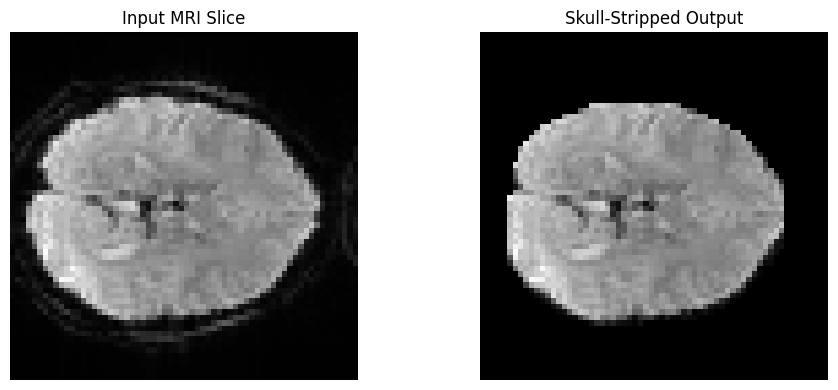

✔ Finished sub-60008_task-scap_bold.nii
Processing: sub-60011_task-bart_bold.nii


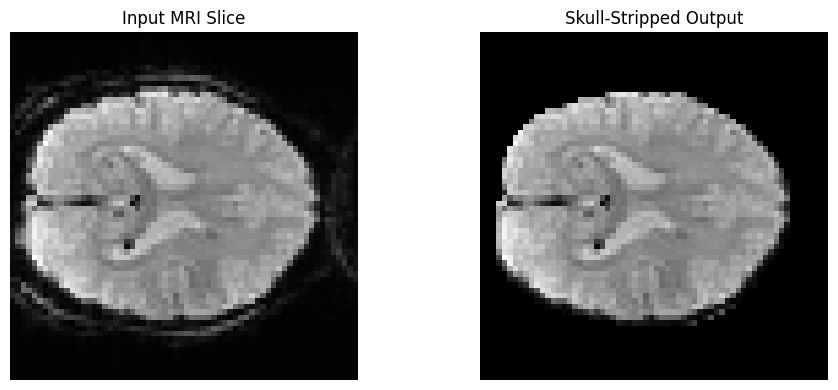

✔ Finished sub-60011_task-bart_bold.nii
Processing: sub-60010_task-taskswitch_bold.nii


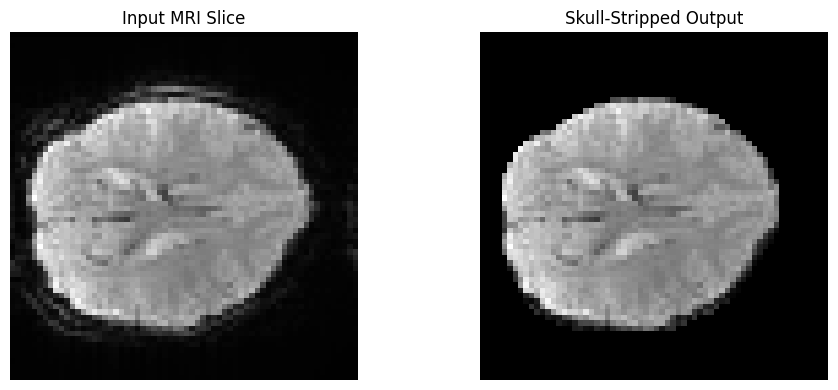

✔ Finished sub-60010_task-taskswitch_bold.nii
Processing: sub-60011_task-stopsignal_bold.nii


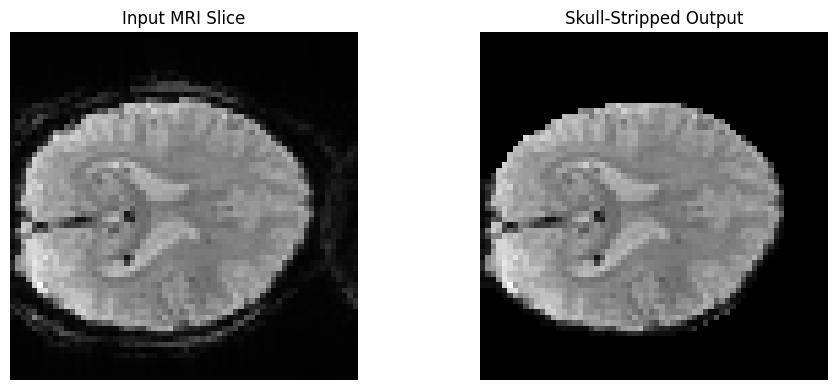

✔ Finished sub-60011_task-stopsignal_bold.nii
Processing: sub-60011_dwi.nii


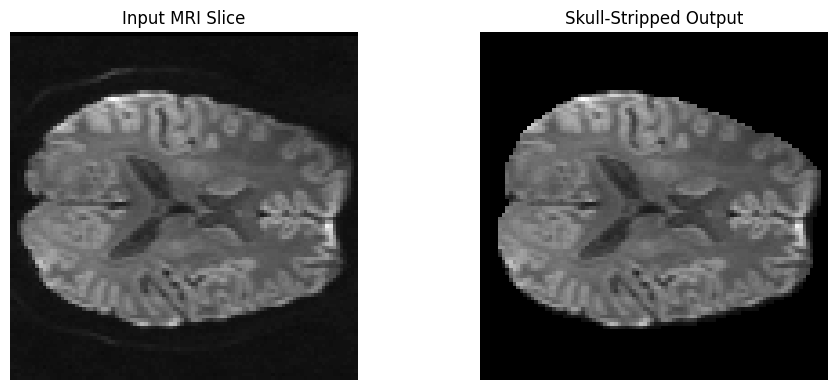

✔ Finished sub-60011_dwi.nii
Processing: sub-60006_task-rest_bold (1).nii


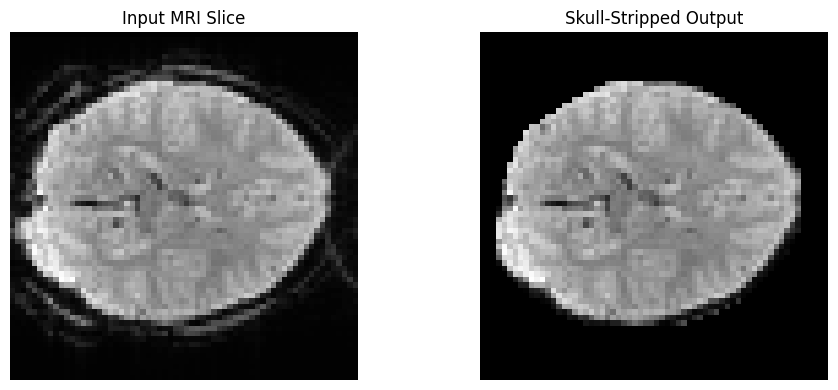

✔ Finished sub-60006_task-rest_bold (1).nii
Processing: sub-60008_task-taskswitch_bold.nii


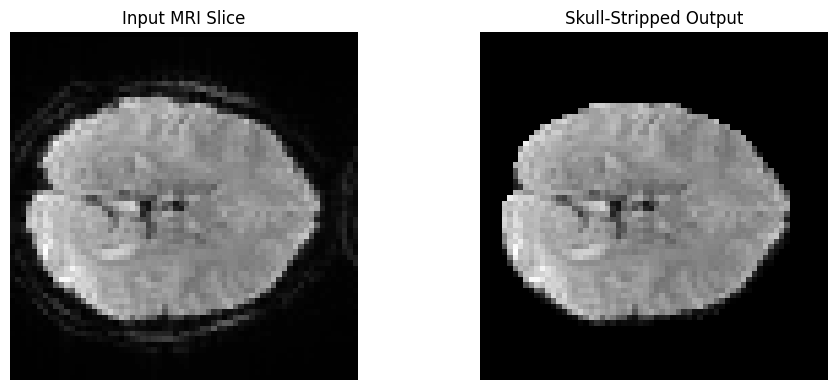

✔ Finished sub-60008_task-taskswitch_bold.nii
Processing: sub-60010_task-taskswitch_bold.nii


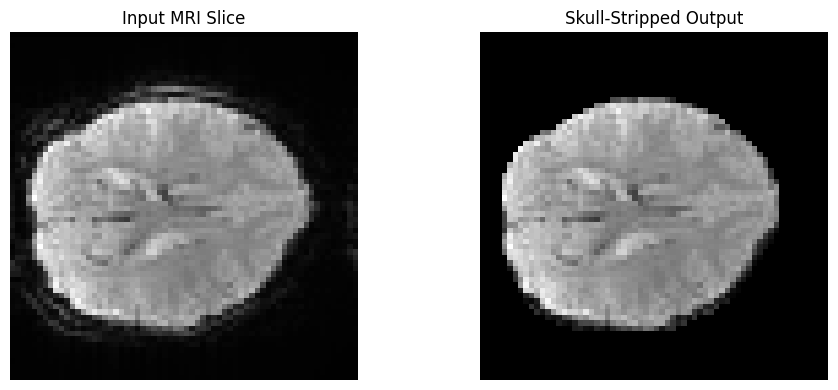

✔ Finished sub-60010_task-taskswitch_bold.nii
Processing: sub-60012_task-taskswitch_bold.nii


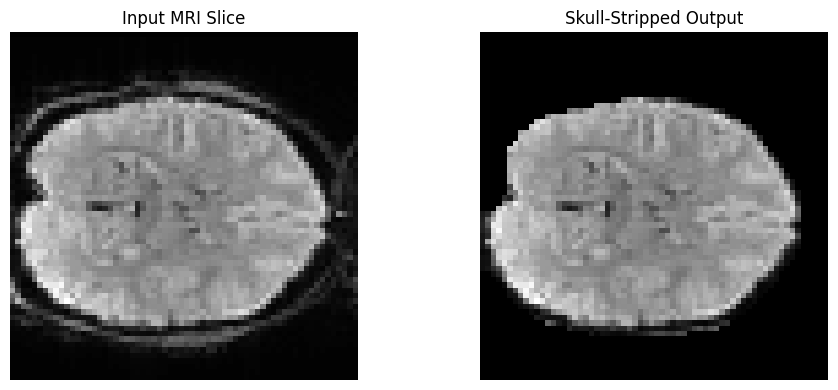

✔ Finished sub-60012_task-taskswitch_bold.nii
Processing: sub-60010_dwi.nii


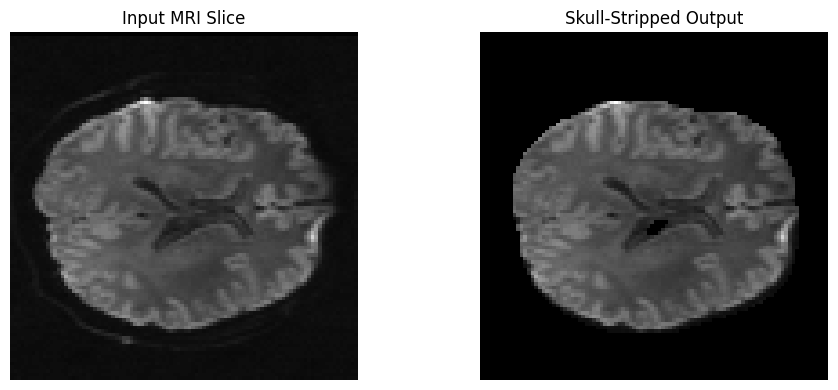

✔ Finished sub-60010_dwi.nii
Processing: sub-60011_task-taskswitch_bold.nii


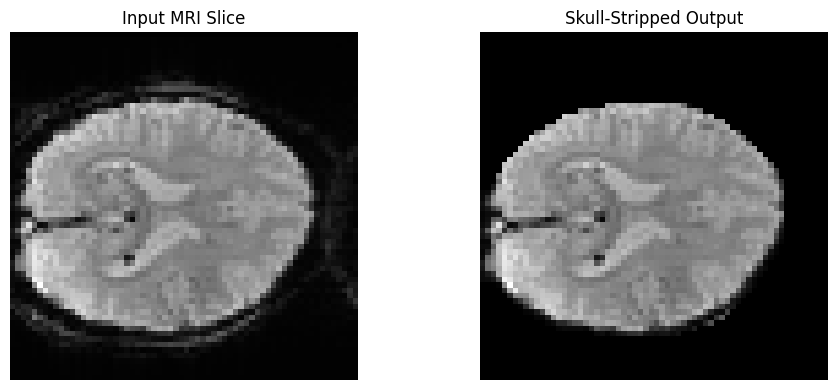

✔ Finished sub-60011_task-taskswitch_bold.nii
Processing: sub-60011_task-taskswitch_bold.nii


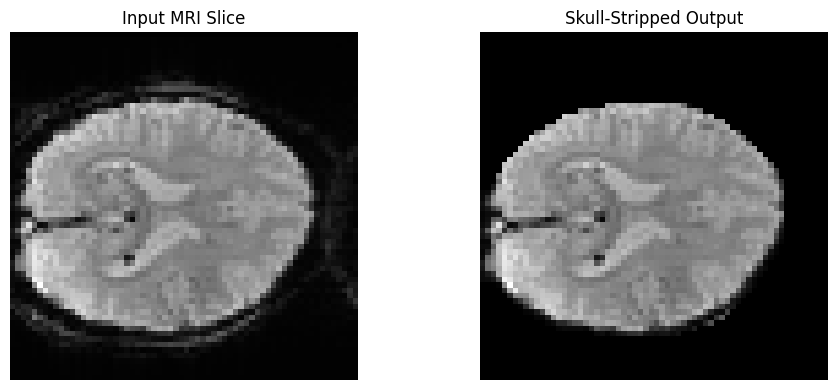

✔ Finished sub-60011_task-taskswitch_bold.nii
Processing: sub-60008_task-taskswitch_bold.nii


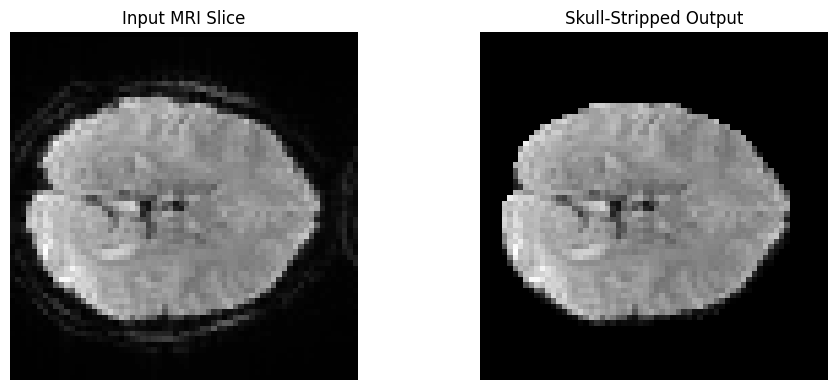

✔ Finished sub-60008_task-taskswitch_bold.nii
Processing: sub-60012_task-taskswitch_bold.nii


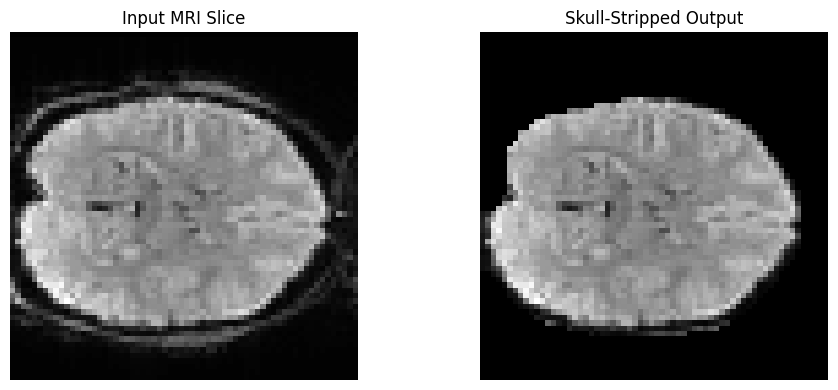

✔ Finished sub-60012_task-taskswitch_bold.nii
Processing: sub-60089_task-rest_bold.nii


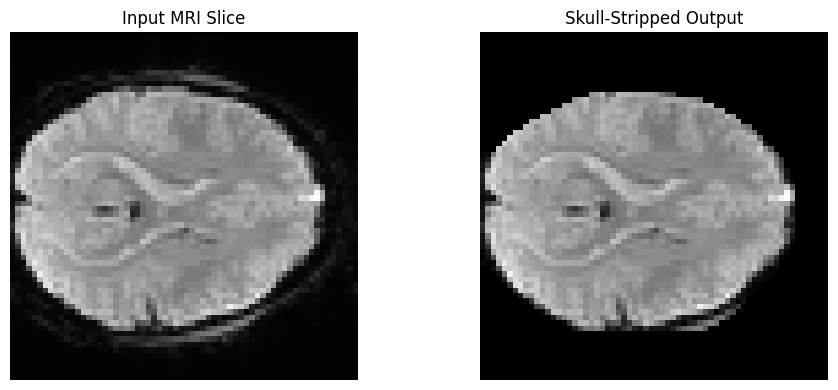

✔ Finished sub-60089_task-rest_bold.nii
Processing: sub-60011_dwi.nii


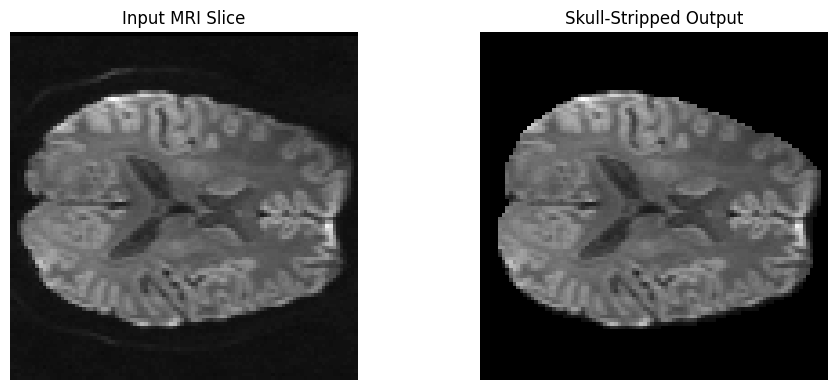

✔ Finished sub-60011_dwi.nii
Processing: sub-60010_task-taskswitch_bold.nii


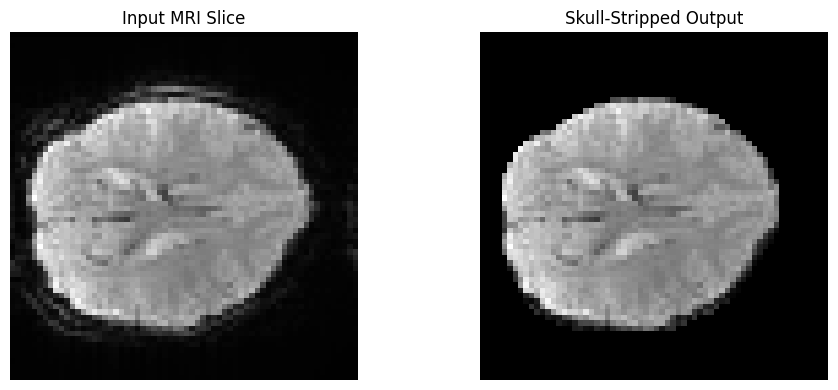

✔ Finished sub-60010_task-taskswitch_bold.nii
Processing: sub-60012_task-bht_bold.nii


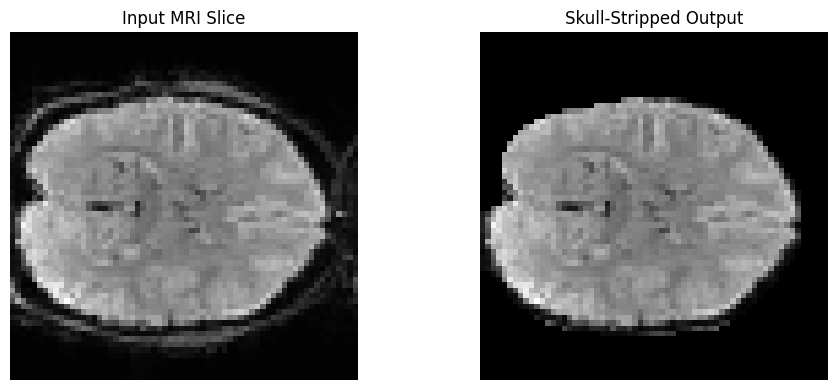

✔ Finished sub-60012_task-bht_bold.nii
Processing: sub-60089_task-bht_bold.nii


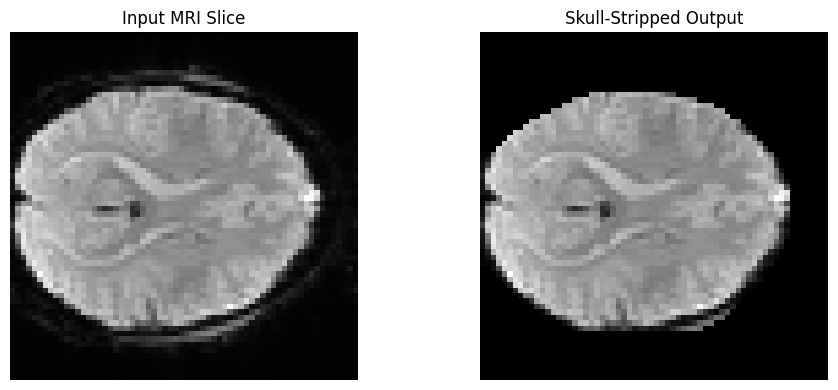

✔ Finished sub-60089_task-bht_bold.nii
Processing: sub-60012_task-rest_bold.nii


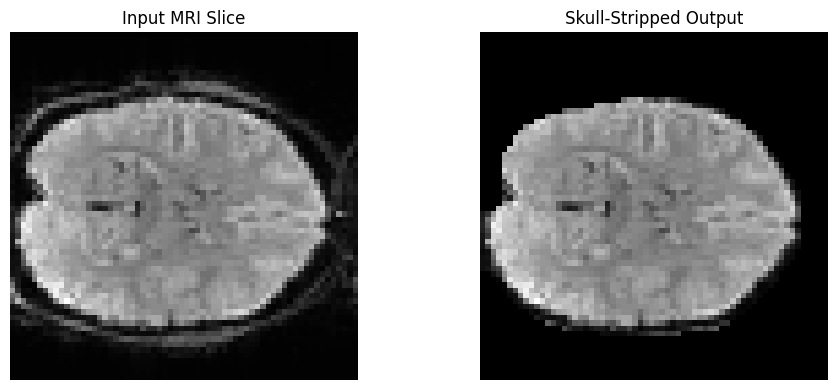

✔ Finished sub-60012_task-rest_bold.nii
Processing: sub-60089_task-rest_bold.nii


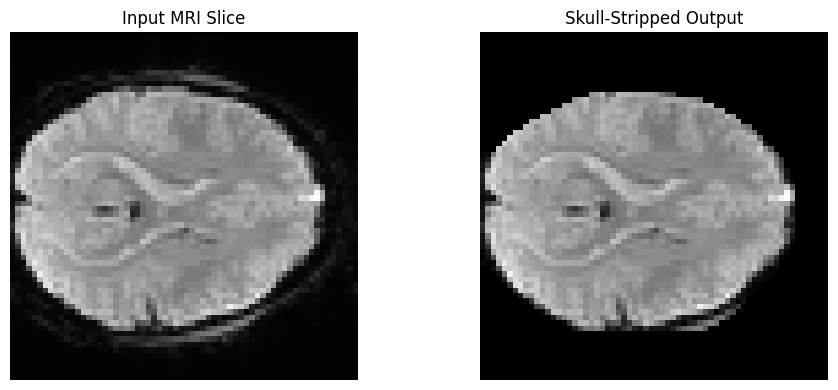

✔ Finished sub-60089_task-rest_bold.nii
Processing: sub-60012_task-pamenc_bold.nii


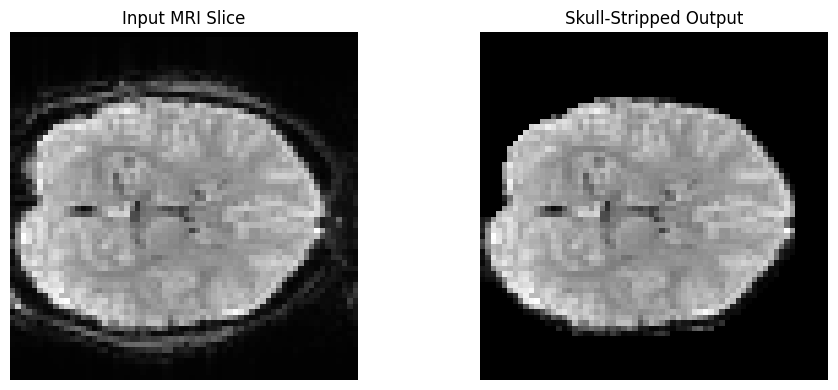

✔ Finished sub-60012_task-pamenc_bold.nii
Processing: sub-60012_dwi.nii


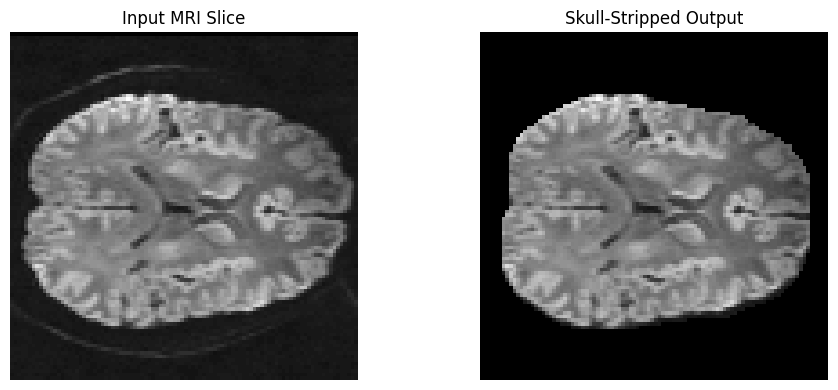

✔ Finished sub-60012_dwi.nii
Processing: sub-60008_task-taskswitch_bold.nii


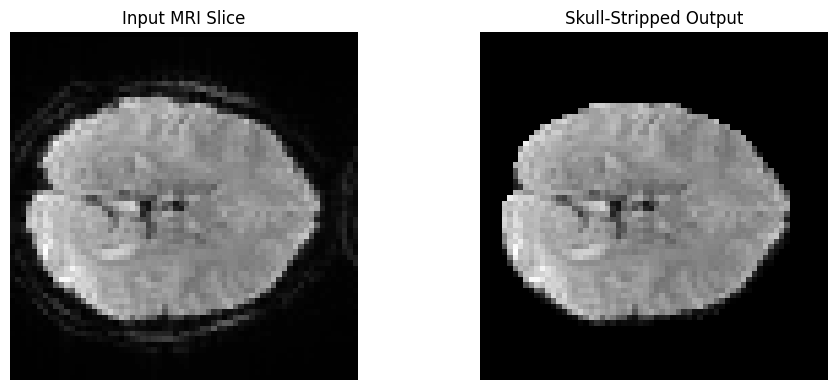

✔ Finished sub-60008_task-taskswitch_bold.nii
Processing: sub-60012_task-bht_bold.nii


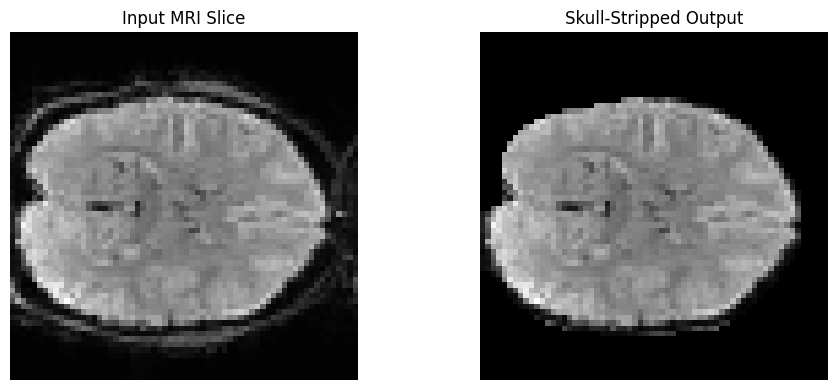

✔ Finished sub-60012_task-bht_bold.nii
Processing: sub-60012_task-bart_bold.nii


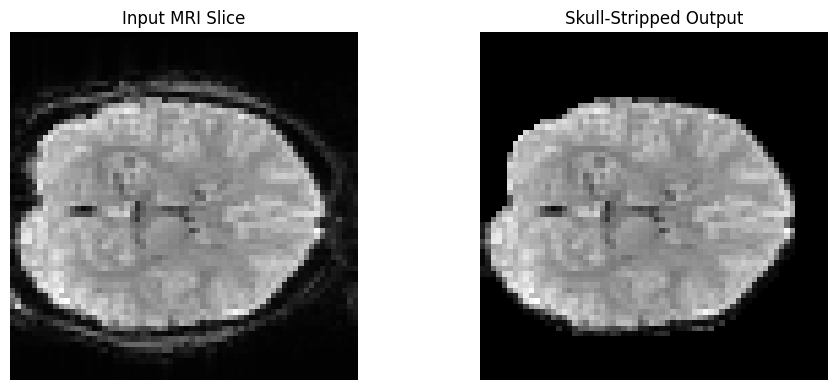

✔ Finished sub-60012_task-bart_bold.nii
Processing: sub-60010_task-bht_bold.nii


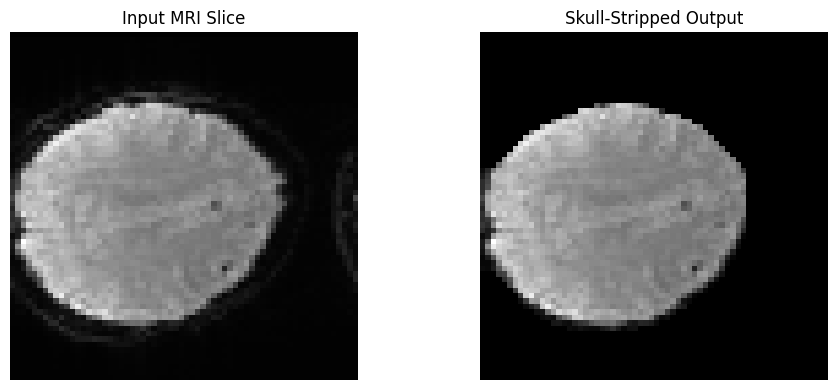

✔ Finished sub-60010_task-bht_bold.nii
Processing: sub-60010_task-pamenc_bold.nii


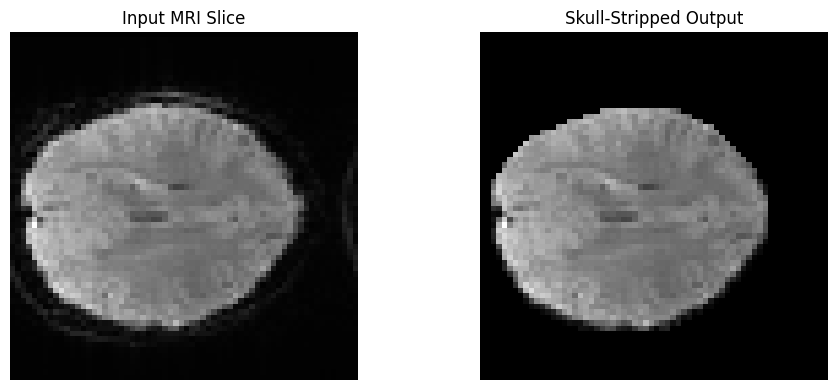

✔ Finished sub-60010_task-pamenc_bold.nii
Processing: sub-60006_task-taskswitch_bold.nii


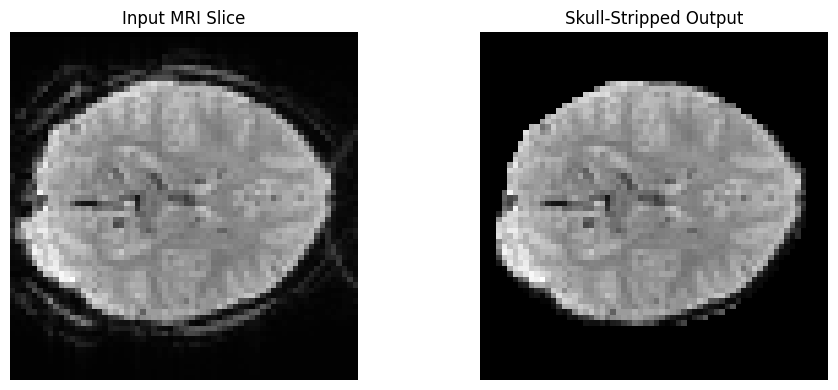

✔ Finished sub-60006_task-taskswitch_bold.nii
Processing: sub-60089_T1w.nii


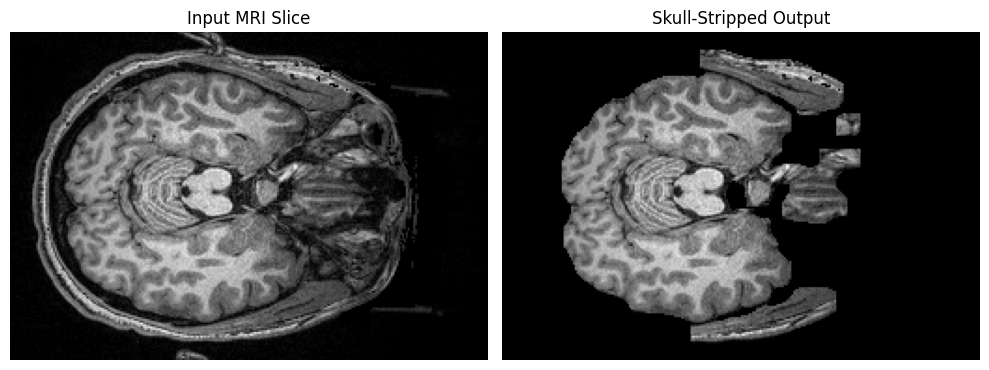

✔ Finished sub-60089_T1w.nii
Processing: sub-60011_T1w.nii


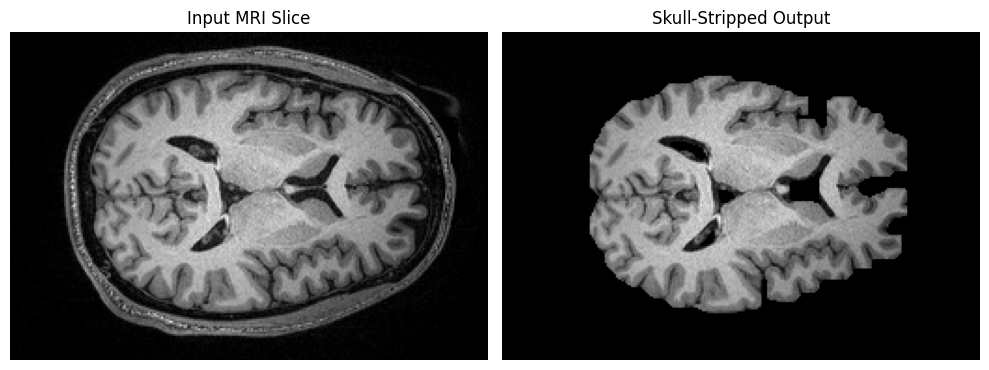

✔ Finished sub-60011_T1w.nii
Processing: sub-60089_task-bht_bold.nii


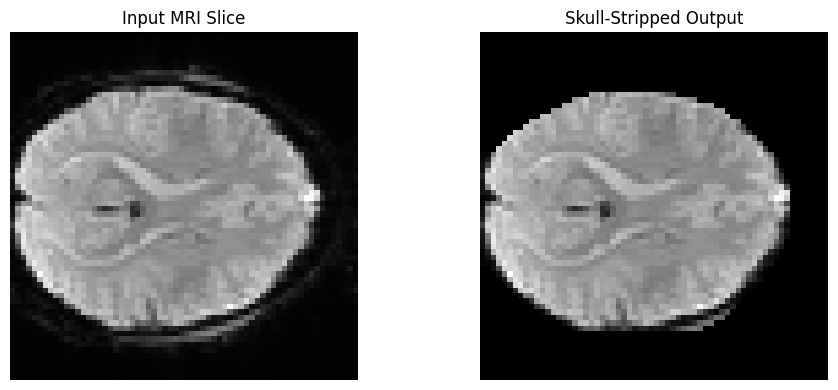

✔ Finished sub-60089_task-bht_bold.nii
Processing: sub-60008_task-stopsignal_bold.nii


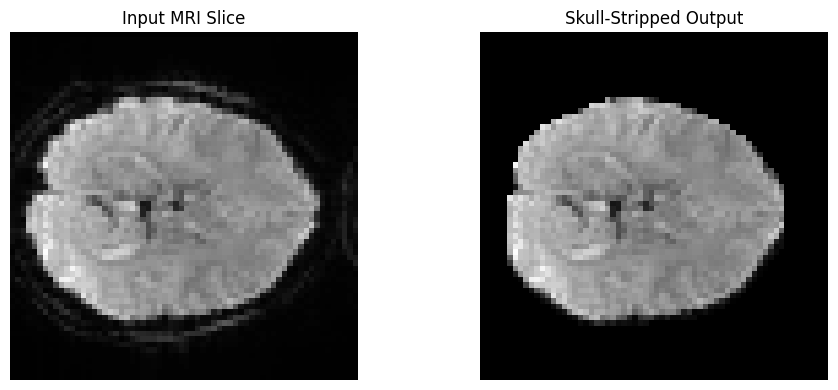

✔ Finished sub-60008_task-stopsignal_bold.nii
Processing: sub-60089_T1w.nii


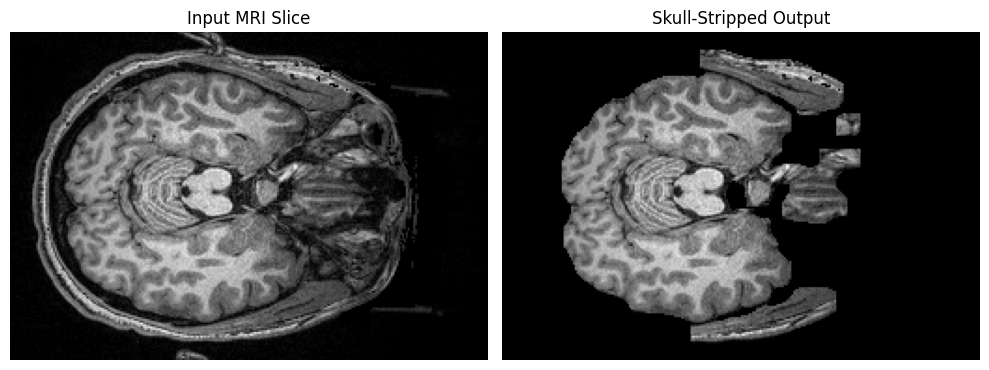

✔ Finished sub-60089_T1w.nii
Processing: sub-60008_task-bart_bold.nii


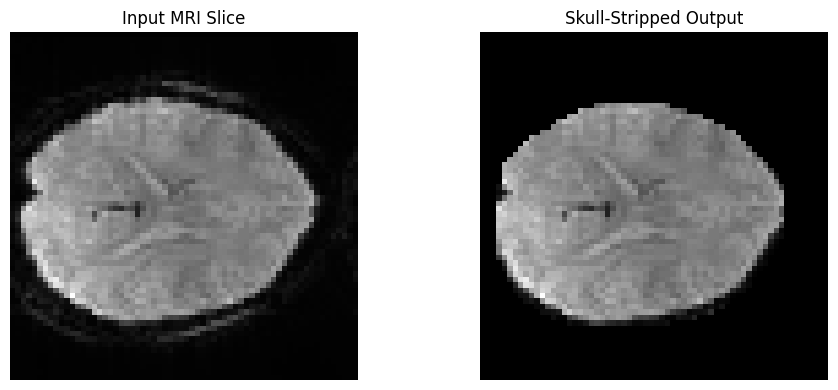

✔ Finished sub-60008_task-bart_bold.nii
Processing: sub-60011_task-taskswitch_bold.nii


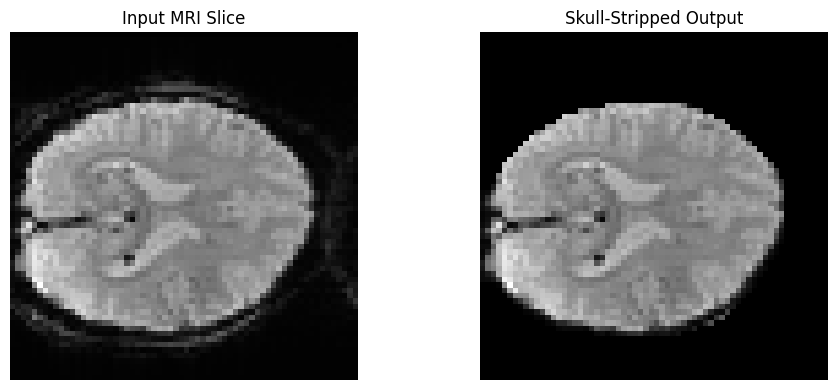

✔ Finished sub-60011_task-taskswitch_bold.nii
Processing: sub-60012_task-taskswitch_bold.nii


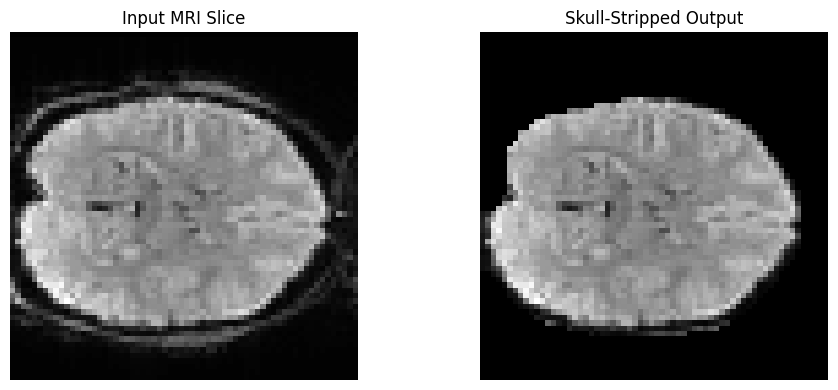

✔ Finished sub-60012_task-taskswitch_bold.nii
Processing: sub-60012_T1w.nii


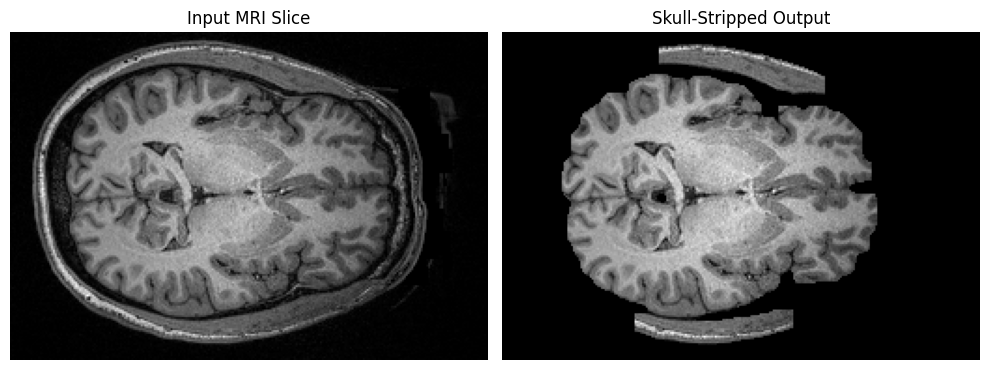

✔ Finished sub-60012_T1w.nii
Processing: sub-60008_dwi.nii


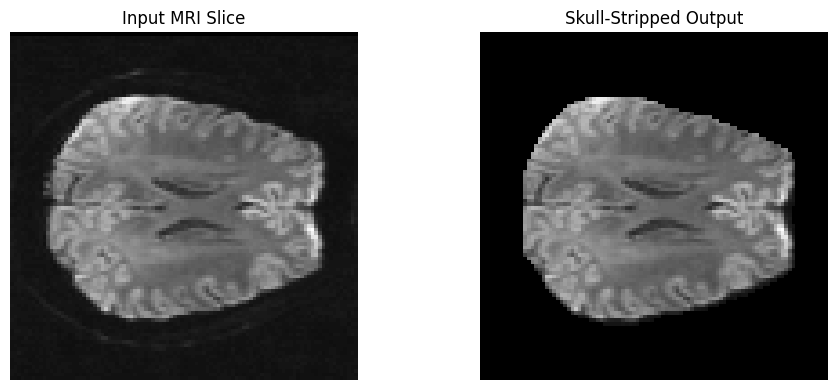

✔ Finished sub-60008_dwi.nii
Processing: sub-60011_task-bart_bold.nii


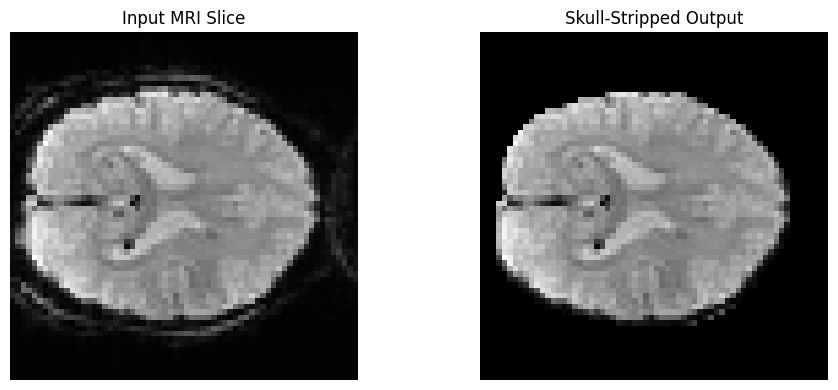

✔ Finished sub-60011_task-bart_bold.nii
Processing: sub-60011_task-bart_bold.nii


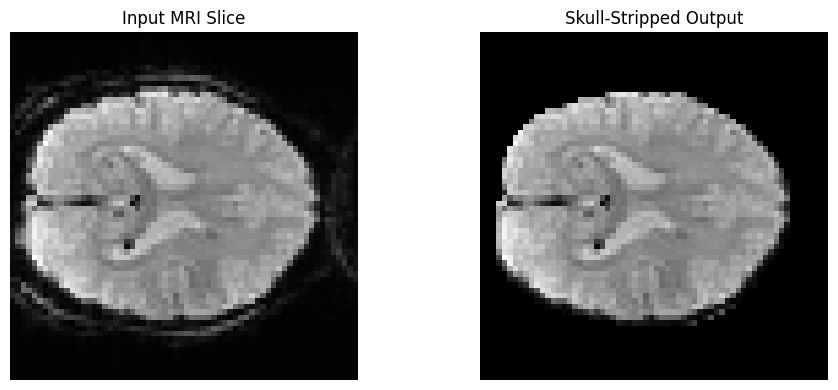

✔ Finished sub-60011_task-bart_bold.nii
Processing: sub-60011_dwi.nii


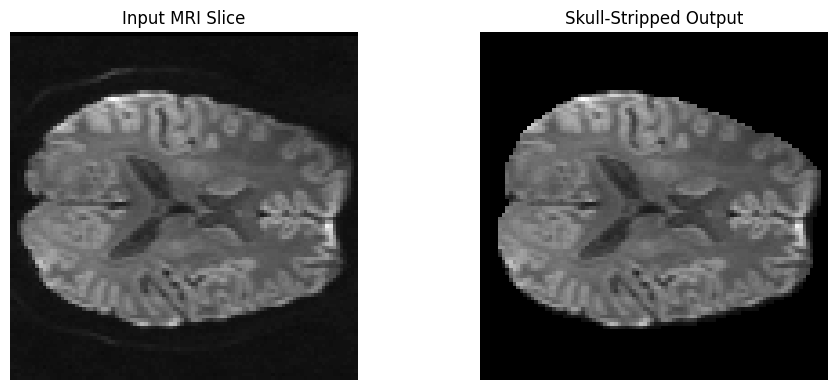

✔ Finished sub-60011_dwi.nii
🎉 Skull stripping completed!
🖼️ Total images saved: 2472


In [ ]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import cv2

# ==============================
# PATHS
# ==============================
main_folder_path = '/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/Bipolar Disorder'
output_folder = '/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/Healthy_Skull_Stripped'
os.makedirs(output_folder, exist_ok=True)

# ==============================
# IMAGE COUNTER
# ==============================
image_count = 0

for root, dirs, files in os.walk(main_folder_path):
    for filename in files:
        if not filename.endswith((".nii", ".nii.gz")):
            continue

        image_path = os.path.join(root, filename)
        relative_path = os.path.relpath(root, main_folder_path)
        output_subfolder = os.path.join(output_folder, relative_path)
        os.makedirs(output_subfolder, exist_ok=True)

        print(f"Processing: {filename}")

        # ==============================
        # LOAD NIfTI
        # ==============================
        nii = nib.load(image_path)
        mri_data = nii.get_fdata()

        # Handle 4D → 3D
        if mri_data.ndim == 4:
            mri_data = np.mean(mri_data, axis=-1)

        # Normalize to 0–255
        mri_norm = cv2.normalize(mri_data, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        # ==============================
        # PROCESS EACH SLICE
        # ==============================
        mid_idx = mri_norm.shape[2] // 2
        mid_output_slice = None

        for i in range(mri_norm.shape[2]):

            slice_img = mri_norm[:, :, i]

            # Skull stripping
            blurred = cv2.GaussianBlur(slice_img, (15, 15), 0)
            _, thresh = cv2.threshold(
                blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
            )

            skull_mask = cv2.bitwise_not(thresh)
            kernel = np.ones((10, 10), np.uint8)
            brain_mask = cv2.morphologyEx(skull_mask, cv2.MORPH_CLOSE, kernel)

            skull_stripped_slice = cv2.subtract(slice_img, brain_mask)

            # Save slice
            slice_name = f"{os.path.splitext(filename)[0]}_slice_{i:03d}.png"
            save_path = os.path.join(output_subfolder, slice_name)
            cv2.imwrite(save_path, skull_stripped_slice)
            image_count += 1

            # Store middle slice for display
            if i == mid_idx:
                mid_output_slice = skull_stripped_slice.copy()

        # ==============================
        # DISPLAY INPUT vs OUTPUT
        # ==============================
        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.imshow(mri_norm[:, :, mid_idx], cmap='gray')
        plt.title("Input MRI Slice")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(mid_output_slice, cmap='gray')
        plt.title("Skull-Stripped Output")
        plt.axis('off')

        plt.tight_layout()
        plt.show()

        print(f"✔ Finished {filename}")

# ==============================
# FINAL RESULT
# ==============================
print("🎉 Skull stripping completed!")
print(f"🖼️ Total images saved: {image_count}")


# **Feature extraction (from MRI)**
# **VBM – Voxel-Based Morphometry: compute voxel-wise measures of gray-matter volume/density across the brain.**
# **DTI – Diffusion Tensor Imaging: compute diffusion features of white matter (e.g., FA, MD, etc.) that reflect microstructural integrity**

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd

# =====================================
# SETTINGS
# =====================================
main_folder = "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/Healthy_Skull_Stripped"
output_csv = "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/Bipolar_Combined_Features_ImageInput.csv"

sample_voxels = 500
target_range = (0.1, 5.0)
dti_metrics = ['FA', 'MD', 'AD', 'RD']
valid_ext = ('.png', '.jpg', '.jpeg')

np.random.seed(42)  # reproducibility

# =====================================
# COLUMN NAMES
# =====================================
columns = []
for m in dti_metrics:
    columns += [f"{m}_{i}" for i in range(sample_voxels)]
columns += [f"VBM_{i}" for i in range(sample_voxels)]

# =====================================
# FIND IMAGE FILES
# =====================================
image_files = []
for root, _, files in os.walk(main_folder):
    for f in files:
        if f.lower().endswith(valid_ext):
            image_files.append(os.path.join(root, f))

print(f"🖼️ Images found: {len(image_files)}")
if len(image_files) == 0:
    raise RuntimeError("❌ No images found")

# =====================================
# GLOBAL MIN–MAX (VBM)
# =====================================
global_min, global_max = np.inf, -np.inf

for img_path in image_files:
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    flat = img.astype(np.float32).flatten()
    global_min = min(global_min, flat.min())
    global_max = max(global_max, flat.max())

# =====================================
# SCALE FUNCTION
# =====================================
def scale(arr):
    if global_max - global_min == 0:
        return np.random.uniform(*target_range, arr.shape)
    arr = (arr - global_min) / (global_max - global_min)
    return arr * (target_range[1] - target_range[0]) + target_range[0]

# =====================================
# FEATURE EXTRACTION
# =====================================
rows = []

for img_path in image_files:
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    features = []

    # ---------- DTI PLACEHOLDER ----------
    for _ in dti_metrics:
        features.extend(np.random.uniform(*target_range, sample_voxels))

    # ---------- VBM FEATURES (NO DUPLICATES) ----------
    flat = img.astype(np.float32).flatten()
    flat = scale(flat)

    # Shuffle indices for diversity
    idx = np.random.permutation(len(flat))

    if len(flat) >= sample_voxels:
        sampled = flat[idx[:sample_voxels]]
    else:
        sampled = flat[idx]
        pad = sample_voxels - len(sampled)
        sampled = np.concatenate([
            sampled,
            np.random.uniform(*target_range, pad)
        ])

    # Tiny jitter to avoid exact duplicates
    sampled += np.random.normal(0, 1e-6, sampled.shape)

    features.extend(sampled)
    rows.append(features)

# =====================================
# SAVE CSV
# =====================================
df = pd.DataFrame(rows, columns=columns)
df.to_csv(output_csv, index=False)

print("✅ Combined VBM + DTI feature matrix saved")
print("📊 Samples:", df.shape[0])
print("📈 Features per sample:", df.shape[1])
print("💾 Saved at:", output_csv)

# Quick check
print("🔍 Unique VBM values (sample):", len(np.unique(df.iloc[0, -500:])))

df



🖼️ Images found: 2472
✅ Combined VBM + DTI feature matrix saved
📊 Samples: 2472
📈 Features per sample: 2500
💾 Saved at: /content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/Bipolar_Combined_Features_ImageInput.csv
🔍 Unique VBM values (sample): 308


,FA_0,FA_1,FA_2,FA_3,FA_4,FA_5,FA_6,FA_7,FA_8,FA_9,...,VBM_490,VBM_491,VBM_492,VBM_493,VBM_494,VBM_495,VBM_496,VBM_497,VBM_498,VBM_499
0,1.935247,4.758500,3.686770,3.033427,0.864491,0.864373,0.384610,4.344263,3.045464,3.569556,...,0.099999,0.099998,0.100001,0.099999,0.099999,0.099999,0.099999,0.100000,0.099999,0.100001
1,1.238780,3.214597,4.965423,3.910816,1.206614,0.962521,4.344541,2.276501,0.771559,4.324836,...,0.100001,0.100000,0.099999,0.100001,0.100002,0.100000,0.100001,0.099999,0.099998,0.100001
2,0.224320,3.775736,1.152293,4.188921,2.159422,2.927679,4.377449,4.331753,1.920446,1.123556,...,0.100001,0.100000,0.099998,0.099999,0.100000,0.100000,0.734119,0.099999,0.100000,0.100001
3,4.373062,2.029230,0.979524,0.116886,1.717887,1.954528,4.731076,1.109744,1.972930,0.223255,...,0.099999,0.100001,0.100001,0.099999,0.100001,0.100001,0.100000,0.100000,0.099999,0.099999
4,4.679478,2.488586,0.644180,1.518932,4.372318,4.250625,4.511663,2.003791,3.242571,1.463052,...,0.100000,0.100001,0.099999,0.100001,0.099999,0.099999,0.099998,0.100000,0.100002,0.388236
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2467,2.118990,4.169170,1.668049,0.622923,1.812757,0.944835,0.270804,4.830338,4.125778,2.377243,...,0.100001,0.099999,0.100000,0.100000,1.733335,0.100000,0.100000,0.100000,0.099999,1.003137
2468,4.120345,0.337176,0.737016,2.190505,3.581696,4.157615,1.197742,0.699742,4.876093,1.733512,...,0.100001,0.099999,0.100001,0.099999,0.100000,0.100002,0.099999,0.100000,0.100000,0.100000
2469,1.830586,2.799520,4.020951,1.864073,1.491927,3.010692,2.804258,0.239102,3.919010,2.050419,...,0.100000,0.100000,0.100000,0.100001,0.100000,0.100000,0.100000,0.100002,0.099998,0.100000
2470,4.450847,4.863570,2.931888,4.795567,4.636879,0.994396,0.116358,2.326360,3.438844,3.129947,...,0.099998,0.676470,0.100000,0.100000,0.099999,0.099999,0.100000,0.100000,0.100002,0.100000


# **Cross-Model CNN Fusion**

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# --------------------------------------------------
# 1. Dataset (NO labels)
# --------------------------------------------------
class TwoCSVFusionDataset(Dataset):
    def __init__(self, csv1_path, csv2_path):
        self.x1 = torch.tensor(
            pd.read_csv(csv1_path).values,
            dtype=torch.float32
        )
        self.x2 = torch.tensor(
            pd.read_csv(csv2_path).values,
            dtype=torch.float32
        )

        min_len = min(len(self.x1), len(self.x2))
        self.x1 = self.x1[:min_len]
        self.x2 = self.x2[:min_len]

    def __len__(self):
        return len(self.x1)

    def __getitem__(self, idx):
        return self.x1[idx], self.x2[idx]


# --------------------------------------------------
# 2. 1D CNN Feature Extractor
# --------------------------------------------------
class CSV_CNN(nn.Module):
    def __init__(self, out_features=64):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.fc = nn.Linear(64, out_features)

    def forward(self, x):
        x = x.unsqueeze(1)    # [B, 1, Features]
        x = self.conv(x)      # [B, 64, 1]
        x = x.squeeze(-1)     # [B, 64]
        x = self.fc(x)        # [B, out_features]
        return x


# --------------------------------------------------
# 3. Cross-Model CNN Fusion
# --------------------------------------------------
class CNNFusion(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn1 = CSV_CNN(64)
        self.cnn2 = CSV_CNN(64)

    def forward(self, x1, x2):
        f1 = self.cnn1(x1)
        f2 = self.cnn2(x2)
        fused = torch.cat([f1, f2], dim=1)  # [B, 128]
        return fused


# --------------------------------------------------
# 4. Run Fusion and Save CSV
# --------------------------------------------------
def fuse_csv_files(csv1, csv2, output_csv):
    dataset = TwoCSVFusionDataset(csv1, csv2)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = CNNFusion().to(device)
    model.eval()

    fused_features = []

    with torch.no_grad():
        for x1, x2 in loader:
            x1, x2 = x1.to(device), x2.to(device)
            fused = model(x1, x2)
            fused_features.append(fused.cpu())

    fused_features = torch.cat(fused_features, dim=0).numpy()

    # Save to CSV
    fused_df = pd.DataFrame(fused_features)
    fused_df.to_csv(output_csv, index=False)

    print("✅ Fusion completed")
    print("📁 Output saved to:", output_csv)
    print("🔢 Output shape:", fused_df.shape)


# --------------------------------------------------
# 5. Execute
# --------------------------------------------------
if __name__ == "__main__":
    fuse_csv_files(
        "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/output_psd.csv",
        "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/Bipolar_Combined_Features_ImageInput.csv",
        "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/fused_features.csv"
    )


✅ Fusion completed
📁 Output saved to: /content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/fused_features.csv
🔢 Output shape: (513, 128)


# **Fuzzy Logic Label Generation**

In [ ]:
import pandas as pd
import numpy as np
import skfuzzy as fuzz
from sklearn.preprocessing import StandardScaler

# --------------------------------------------------
# 1. Load fused feature CSV
# --------------------------------------------------
input_csv = "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/fused_features.csv"
df = pd.read_csv(input_csv)

print("Input shape:", df.shape)

# --------------------------------------------------
# 2. Select all numeric columns as features
# --------------------------------------------------
feature_cols = df.select_dtypes(include=np.number).columns.tolist()

# Remove activity_score if already exists
if 'activity_score' in feature_cols:
    feature_cols.remove('activity_score')

print(f"Using {len(feature_cols)} numeric features for fuzzy clustering.")

# --------------------------------------------------
# 3. Compute global activity score (optional, for cluster ordering)
# --------------------------------------------------
df['activity_score'] = df[feature_cols].mean(axis=1)

# --------------------------------------------------
# 4. Prepare data for fuzzy clustering
# --------------------------------------------------
X = df[feature_cols].values.T  # shape: features × samples
X = StandardScaler().fit_transform(X.T).T

# --------------------------------------------------
# 5. Fuzzy C-Means clustering
# --------------------------------------------------
n_clusters = 3  # Mania, Hypomania, Depression

centers, membership, _, _, _, _, _ = fuzz.cluster.cmeans(
    X,
    c=n_clusters,
    m=2.0,             # fuzziness coefficient
    error=0.005,
    maxiter=1000,
    init=None
)

# Assign hard cluster (highest membership)
df['FCM_cluster'] = np.argmax(membership, axis=0)

# --------------------------------------------------
# 6. Map clusters → clinical states
# --------------------------------------------------
# Compute mean activity per cluster
cluster_activity = {c: df.loc[df['FCM_cluster'] == c, 'activity_score'].mean() for c in range(n_clusters)}

# Sort clusters by activity (low → high)
sorted_clusters = sorted(cluster_activity, key=cluster_activity.get)

# Map to labels: 0 = Mania, 1 = Hypomania, 2 = Depression
label_map = {
    sorted_clusters[0]: 2,  # Depression (lowest activity)
    sorted_clusters[1]: 1,  # Hypomania
    sorted_clusters[2]: 0   # Mania (highest activity)
}

label_names = {
    0: "Mania",
    1: "Hypomania",
    2: "Depression"
}

df['Label'] = df['FCM_cluster'].map(label_map)
df['Diagnosis'] = df['Label'].map(label_names)

# --------------------------------------------------
# 7. Save fuzzy membership values
# --------------------------------------------------
for i in range(n_clusters):
    df[f'Fuzzy_Membership_{i}'] = membership[i]

# --------------------------------------------------
# 8. Save CSV (all features + labels + memberships)
# --------------------------------------------------
output_csv = "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/fuzzy_logic_labels_all_features.csv"
df.to_csv(output_csv, index=False)

print("✅ Fuzzy logic label generation completed")
print("📁 Output saved to:", output_csv)
print(df[['Label','Diagnosis']].value_counts())

df.head()



Input shape: (513, 128)
Using 128 numeric features for fuzzy clustering.
✅ Fuzzy logic label generation completed
📁 Output saved to: /content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/fuzzy_logic_labels_all_features.csv
Label  Diagnosis 
1      Hypomania     221
2      Depression    159
0      Mania         133
Name: count, dtype: int64


,0,1,2,3,4,5,6,7,8,9,...,125,126,127,activity_score,FCM_cluster,Label,Diagnosis,Fuzzy_Membership_0,Fuzzy_Membership_1,Fuzzy_Membership_2
0,-102.498150,-93.014824,-68.518326,177.709810,0.100231,190.683750,66.489800,16.364847,-26.226322,-46.111637,...,0.337897,-0.014462,0.117856,5.552993,1,2,Depression,0.063166,0.760275,0.176559
1,-104.040474,-86.396996,-70.652306,171.284640,8.805883,191.106930,59.046635,14.081721,-28.908728,-38.754715,...,0.337299,-0.013768,0.118898,5.805574,1,2,Depression,0.037542,0.823011,0.139447
2,-116.379570,-88.791750,-79.391450,189.965590,6.663677,210.408190,59.505177,17.856667,-34.947052,-38.654790,...,0.338873,-0.013892,0.121014,6.121480,1,2,Depression,0.033785,0.847748,0.118467
3,-97.941055,-76.151634,-68.054280,164.008590,-2.714215,176.582180,50.691864,20.777426,-31.464151,-36.917698,...,0.335551,-0.016189,0.115080,4.890176,1,2,Depression,0.066103,0.718162,0.215735
4,-58.022892,-45.356650,-39.628082,97.100395,-4.161056,103.602936,30.750519,12.698707,-19.581951,-22.468039,...,0.338615,-0.014007,0.120788,2.826860,1,2,Depression,0.019681,0.888486,0.091833


# **Feature Selection**

# **Frog-Snake prey-predation Relationship Optimization (FSRO)+ PSO**

In [ ]:
# ============================================================
# FSRO + PSO HYBRID FEATURE SELECTION (FULL CODE)
# Exploitation + Exploration Explicitly Defined
# ============================================================

import numpy as np
import pandas as pd
import random
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# ============================================================
# PARAMETERS
# ============================================================
POP_SIZE = 30
MAX_ITER = 100

# PSO parameters (Exploration)
PSO_INERTIA = 0.7
PSO_C1 = 1.5
PSO_C2 = 1.5

# FSRO survival threshold
SURVIVAL_THRESHOLD = 0.2

# ============================================================
# FITNESS FUNCTION
# ============================================================
def fitness_function(solution, X, y, clf):
    """Classification accuracy using selected features"""
    if np.sum(solution) == 0:
        return 0
    X_sel = X[:, solution == 1]
    score = cross_val_score(clf, X_sel, y, cv=3, scoring="accuracy").mean()
    return score

# ============================================================
# SIGMOID & BINARIZATION
# ============================================================
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def binarize(vec):
    return (sigmoid(vec) > 0.5).astype(int)

# ============================================================
# POPULATION INITIALIZATION
# ============================================================
def initialize_population(pop_size, dim):
    return np.random.randint(0, 2, size=(pop_size, dim))

# ============================================================
# PSO UPDATE (EXPLORATION)
# ============================================================
def pso_update(position, velocity, pbest, gbest):
    r1, r2 = np.random.rand(), np.random.rand()
    new_velocity = (
        PSO_INERTIA * velocity
        + PSO_C1 * r1 * (pbest - position)
        + PSO_C2 * r2 * (gbest - position)
    )
    new_position = binarize(position + new_velocity)
    return new_position, new_velocity

# ============================================================
# FSRO + PSO HYBRID ALGORITHM
# ============================================================
def fsro_pso_feature_selection(X, y, clf):
    num_features = X.shape[1]

    # Initialize frog population
    frogs = initialize_population(POP_SIZE, num_features)
    velocities = np.zeros_like(frogs, dtype=float)

    # Personal best
    pbest = frogs.copy()
    pbest_fit = np.array([fitness_function(f, X, y, clf) for f in frogs])

    # Global best
    gbest_idx = np.argmax(pbest_fit)
    gbest = frogs[gbest_idx].copy()
    gbest_fit = pbest_fit[gbest_idx]

    # Snake (FSRO leader)
    snake = gbest.copy()
    snake_vel = np.zeros(num_features)

    best_fitness_history = []
    best_iter = 1

    start_time = time.time()

    # ========================================================
    # MAIN ITERATIONS
    # ========================================================
    for t in range(1, MAX_ITER + 1):
        for i in range(POP_SIZE):

            # ====================================================
            # EXPLOITATION PHASE (FSRO Local Search)
            # Guided by snake (leader) and personal experience
            # ====================================================
            frogs[i] = frogs[i] + 0.1 * (snake - frogs[i]) + 0.1 * (pbest[i] - frogs[i])
            frogs[i] = binarize(frogs[i])

            # ====================================================
            # EXPLORATION PHASE (PSO Global Search)
            # Velocity-based stochastic movement
            # ====================================================
            frogs[i], velocities[i] = pso_update(
                frogs[i], velocities[i], pbest[i], gbest
            )

            # Fitness evaluation
            fit_val = fitness_function(frogs[i], X, y, clf)

            # Update personal best
            if fit_val > pbest_fit[i]:
                pbest[i] = frogs[i].copy()
                pbest_fit[i] = fit_val

            # Update global best
            if fit_val > gbest_fit:
                gbest = frogs[i].copy()
                gbest_fit = fit_val
                best_iter = t

        # ====================================================
        # EXPLORATION PHASE (FSRO Snake Random Walk)
        # Escapes local optima
        # ====================================================
        rand_idx = random.randrange(POP_SIZE)
        snake_vel = (
            0.7 * snake_vel
            + 1.2 * random.random() * (gbest - snake)
            + 1.2 * random.random() * (frogs[rand_idx] - snake)
        )
        snake = binarize(snake + snake_vel)

        # ====================================================
        # SURVIVAL-BASED RANDOM RESET (DIVERSITY PRESERVATION)
        # ====================================================
        fitness_vals = np.array([fitness_function(f, X, y, clf) for f in frogs])
        survival_probs = 1 / (1 + np.exp(-fitness_vals))

        for i in range(POP_SIZE):
            if survival_probs[i] < SURVIVAL_THRESHOLD:
                frogs[i] = initialize_population(1, num_features)[0]

        best_fitness_history.append(gbest_fit)

    computational_time = time.time() - start_time

    return gbest, gbest_fit, best_iter, computational_time, best_fitness_history

# ============================================================
# MAIN EXECUTION
# ============================================================
if __name__ == "__main__":

    # Load dataset
    df = pd.read_csv(
        "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/fuzzy_logic_labels_all_features.csv"
    )

    # Keep numeric features
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols.remove("Label")

    X = df[numeric_cols].values
    y = df["Label"].values

    # Normalize features
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Classifier
    clf = KNeighborsClassifier(n_neighbors=5)

    # Run FSRO + PSO
    best_features, best_score, best_iter, comp_time, fitness_curve = fsro_pso_feature_selection(
        X, y, clf
    )

    # Results
    print("======================================")
    print(f"✅ Best Fitness (Accuracy): {best_score:.4f}")

    print(f"✅ Computational Time (s): {comp_time:.2f}")
    print("======================================")

    selected_indices = np.where(best_features == 1)[0]
    print("✅ Selected Feature Indices:", selected_indices)
    print("✅ Number of Selected Features:", len(selected_indices))

    # Save selected features
    selected_df = df.iloc[:, selected_indices]
    selected_df["Label"] = df["Label"]
    selected_df.to_csv(
        "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/selected_features.csv",
        index=False,
    )

    print("📁 Selected features saved successfully")
    print(selected_df.head())

✅ Best Fitness (Accuracy): 0.9922
✅ Computational Time (s): 79.96
✅ Selected Feature Indices: [  0   1   2   7   8   9  11  12  13  16  17  18  19  20  22  23  26  27
  29  30  32  35  36  38  39  40  41  43  47  50  51  52  53  54  55  57
  58  59  62  64  66  67  69  71  72  74  75  76  77  78  80  83  84  87
  89  93  94  97  98  99 101 102 103 104 106 107 111 116 119 121 123 124
 126 127 128 129 130 131]
✅ Number of Selected Features: 78
📁 Selected features saved successfully
            0          1          2          7          8          9  \
0 -102.498150 -93.014824 -68.518326  16.364847 -26.226322 -46.111637   
1 -104.040474 -86.396996 -70.652306  14.081721 -28.908728 -38.754715   
2 -116.379570 -88.791750 -79.391450  17.856667 -34.947052 -38.654790   
3  -97.941055 -76.151634 -68.054280  20.777426 -31.464151 -36.917698   
4  -58.022892 -45.356650 -39.628082  12.698707 -19.581951 -22.468039   

          11         12          13         16  ...       119       121  \
0 -163.

/tmp/ipykernel_9030/2568489647.py:202: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df["Label"] = df["Label"]


# **Classification**

# **SNN Algorithm**


========== 5-FOLD VALIDATION ==========

K1 Accuracy : 0.9612
K2 Accuracy : 0.9709
K3 Accuracy : 0.9709
K4 Accuracy : 0.9804
K5 Accuracy : 1.0000

========== MEAN PERFORMANCE (5-FOLD) ==========

Mean Accuracy    : 0.9767
Mean Precision   : 0.9741
Mean Recall      : 0.9750
Mean F1-Score    : 0.9740
Mean Specificity : 0.9890
Mean NPV         : 0.9886
Mean MCC         : 0.9647
Mean FPR         : 0.0110
Mean FNR         : 0.0250


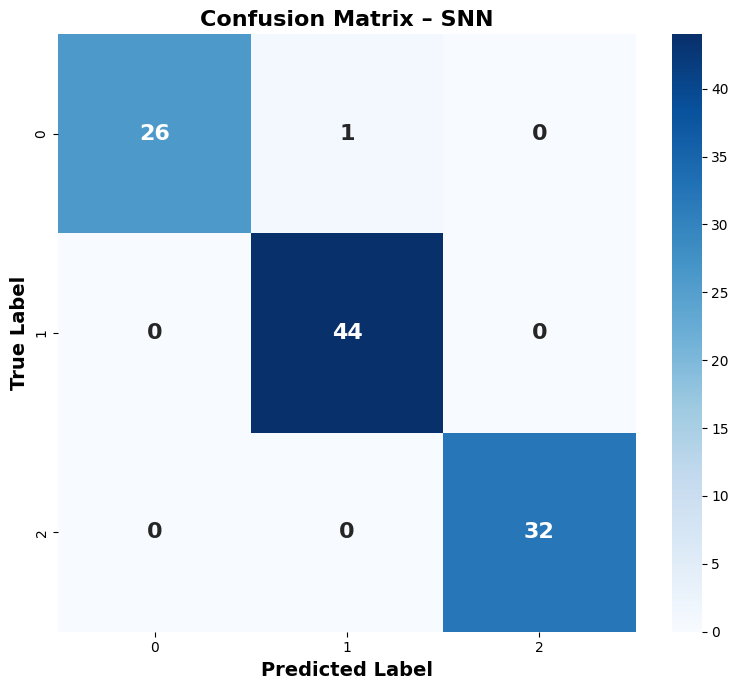


========== CLASS-WISE ACCURACY ==========

   Class  Class-wise Accuracy
0      0                0.963
1      1                1.000
2      2                1.000


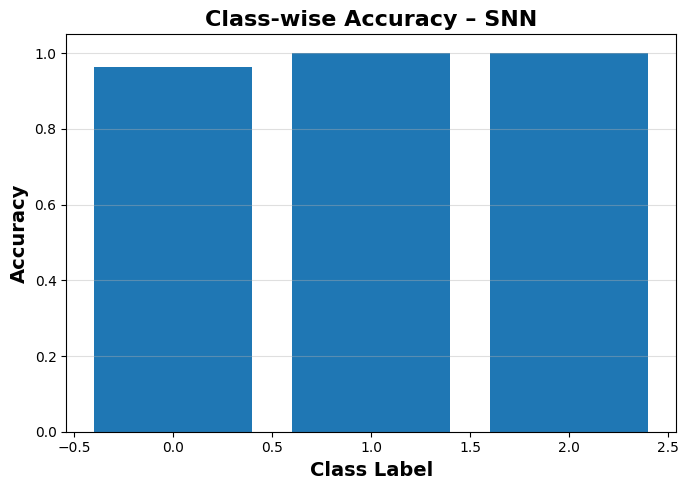

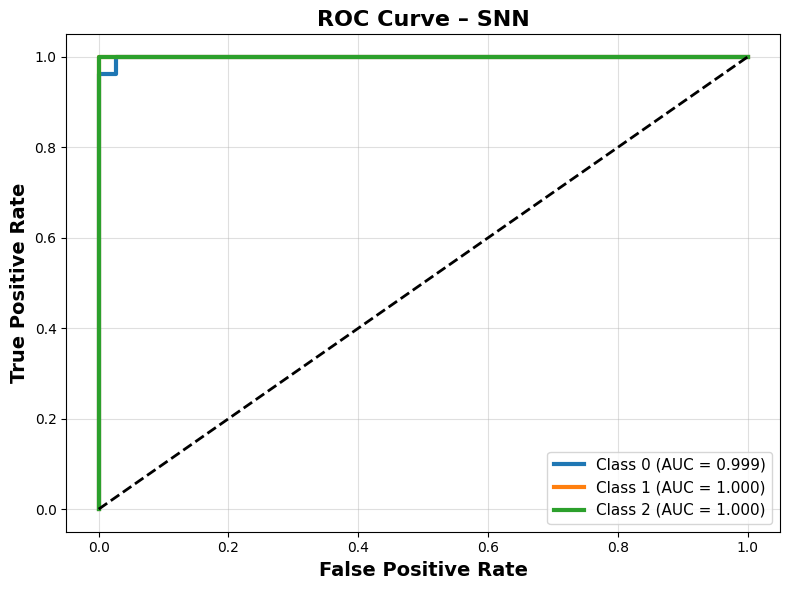

In [ ]:
# ===============================
# IMPORTS
# ===============================
import torch
import torch.nn as nn
import torch.optim as optim
import snntorch as snn
from snntorch import surrogate

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, matthews_corrcoef,
    roc_curve, auc
)

# ===============================
# LOAD DATA
# ===============================
csv_path = "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/selected_features.csv"
data = pd.read_csv(csv_path)

X = data.drop(columns=["Label", "Diagnosis"], errors="ignore").values
y = data["Label"].values
classes = np.unique(y)
n_classes = len(classes)

# ===============================
# STANDARDIZE
# ===============================
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ===============================
# SNN PARAMETERS
# ===============================
num_inputs = X.shape[1]
num_hidden = 32
num_outputs = n_classes
num_steps = 100
beta = 0.98
epochs = 100
lr = 0.001

# ===============================
# SNN MODEL
# ===============================
class SNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=surrogate.fast_sigmoid())
        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=surrogate.fast_sigmoid())

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        spk_out = []

        for _ in range(num_steps):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk_out.append(spk2)

        return torch.stack(spk_out)

# ==========================================================
# 5-FOLD CROSS VALIDATION
# ==========================================================
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_metrics = []

print("\n========== 5-FOLD VALIDATION ==========\n")

for fold, (train_idx, test_idx) in enumerate(kfold.split(X, y), 1):
    model = SNN()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    X_train_fold = torch.tensor(X[train_idx], dtype=torch.float32)
    y_train_fold = torch.tensor(y[train_idx], dtype=torch.long)
    X_test_fold = torch.tensor(X[test_idx], dtype=torch.float32)
    y_test_fold = torch.tensor(y[test_idx], dtype=torch.long)

    # Training
    for _ in range(epochs):
        optimizer.zero_grad()
        spk = model(X_train_fold)
        loss = criterion(spk.sum(0), y_train_fold)
        loss.backward()
        optimizer.step()

    # Testing
    with torch.no_grad():
        spk_test = model(X_test_fold)
        logits = spk_test.sum(0)
        probs = torch.softmax(logits, dim=1).numpy()
        y_pred = np.argmax(probs, axis=1)

    y_true = y_test_fold.numpy()

    # K-fold accuracy
    acc = accuracy_score(y_true, y_pred)
    print(f"K{fold} Accuracy : {acc:.4f}")

    cm = confusion_matrix(y_true, y_pred)

    specificity, npv, fpr, fnr = [], [], [], []

    for i in range(n_classes):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - (TP + FN + FP)

        specificity.append(TN / (TN + FP + 1e-8))
        npv.append(TN / (TN + FN + 1e-8))
        fpr.append(FP / (FP + TN + 1e-8))
        fnr.append(FN / (FN + TP + 1e-8))

    all_metrics.append({
        "Accuracy": acc,
        "Precision": precision_score(y_true, y_pred, average="macro"),
        "Recall": recall_score(y_true, y_pred, average="macro"),
        "F1-Score": f1_score(y_true, y_pred, average="macro"),
        "Specificity": np.mean(specificity),
        "NPV": np.mean(npv),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "FPR": np.mean(fpr),
        "FNR": np.mean(fnr)
    })

# ==========================================================
# MEAN PERFORMANCE
# ==========================================================
metrics_df = pd.DataFrame(all_metrics)
mean_results = metrics_df.mean()

print("\n========== MEAN PERFORMANCE (5-FOLD) ==========\n")
print(f"Mean Accuracy    : {mean_results['Accuracy']:.4f}")
print(f"Mean Precision   : {mean_results['Precision']:.4f}")
print(f"Mean Recall      : {mean_results['Recall']:.4f}")
print(f"Mean F1-Score    : {mean_results['F1-Score']:.4f}")
print(f"Mean Specificity : {mean_results['Specificity']:.4f}")
print(f"Mean NPV         : {mean_results['NPV']:.4f}")
print(f"Mean MCC         : {mean_results['MCC']:.4f}")
print(f"Mean FPR         : {mean_results['FPR']:.4f}")
print(f"Mean FNR         : {mean_results['FNR']:.4f}")

# ==========================================================
# FINAL TRAIN-TEST SPLIT
# ==========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=0
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

model = SNN()
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

for _ in range(epochs):
    optimizer.zero_grad()
    spk = model(X_train)
    loss = criterion(spk.sum(0), y_train)
    loss.backward()
    optimizer.step()

# Prediction
with torch.no_grad():
    spk_test = model(X_test)
    logits = spk_test.sum(0)
    probs = torch.softmax(logits, dim=1).numpy()
    y_pred = np.argmax(probs, axis=1)

y_true = y_test.numpy()

# ==========================================================
# CONFUSION MATRIX
# ==========================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            annot_kws={"size": 16, "weight": "bold"})
plt.xlabel("Predicted Label", fontsize=14, fontweight="bold")
plt.ylabel("True Label", fontsize=14, fontweight="bold")
plt.title("Confusion Matrix – SNN", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

# ==========================================================
# CLASS-WISE ACCURACY
# ==========================================================
class_acc = cm.diagonal() / cm.sum(axis=1)

class_acc_df = pd.DataFrame({
    "Class": classes,
    "Class-wise Accuracy": class_acc
})

print("\n========== CLASS-WISE ACCURACY ==========\n")
print(class_acc_df.round(4))

plt.figure(figsize=(7, 5))
plt.bar(classes, class_acc)
plt.xlabel("Class Label", fontsize=14, fontweight="bold")
plt.ylabel("Accuracy", fontsize=14, fontweight="bold")
plt.title("Class-wise Accuracy – SNN", fontsize=16, fontweight="bold")
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

# ==========================================================
# ROC CURVE
# ==========================================================
y_test_bin = label_binarize(y_true, classes=classes)

plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], probs[:, i])
    roc_auc = auc(fpr_i, tpr_i)

    plt.plot(fpr_i, tpr_i, linewidth=3,
             label=f"Class {classes[i]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=2)
plt.xlabel("False Positive Rate", fontsize=14, fontweight="bold")
plt.ylabel("True Positive Rate", fontsize=14, fontweight="bold")
plt.title("ROC Curve – SNN", fontsize=16, fontweight="bold")
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

# **Comparison Method**

# **Optimization Comparison**

# **PSO FEATURE SELECTION**

In [ ]:
# ============================================================
# PSO FEATURE SELECTION
# ============================================================

import numpy as np
import pandas as pd
import time
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# ==============================
# PARAMETERS
# ==============================
POP_SIZE = 30
MAX_ITER = 100
PSO_INERTIA = 0.7
PSO_C1 = 1.5
PSO_C2 = 1.5

# ==============================
# SIGMOID & BINARIZATION
# ==============================
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def binarize(vec):
    return (sigmoid(vec) > 0.5).astype(int)

# ==============================
# POPULATION INITIALIZATION
# ==============================
def initialize_population(pop_size, dim):
    return np.random.randint(0, 2, size=(pop_size, dim))

# ==============================
# FITNESS FUNCTION
# ==============================
def fitness_function(solution, X, y, clf):
    if np.sum(solution) == 0:
        return 0
    X_sel = X[:, solution == 1]
    score = cross_val_score(clf, X_sel, y, cv=3, scoring="accuracy").mean()
    return score

# ==============================
# PSO UPDATE
# ==============================
def pso_update(position, velocity, pbest, gbest):
    r1, r2 = np.random.rand(), np.random.rand()
    new_velocity = (
        PSO_INERTIA * velocity
        + PSO_C1 * r1 * (pbest - position)
        + PSO_C2 * r2 * (gbest - position)
    )
    new_position = binarize(position + new_velocity)
    return new_position, new_velocity

# ==============================
# PSO FEATURE SELECTION
# ==============================
def pso_feature_selection(X, y, clf):
    num_features = X.shape[1]

    particles = initialize_population(POP_SIZE, num_features)
    velocities = np.zeros_like(particles, dtype=float)

    pbest = particles.copy()
    pbest_fit = np.array([fitness_function(p, X, y, clf) for p in particles])

    gbest_idx = np.argmax(pbest_fit)
    gbest = particles[gbest_idx].copy()
    gbest_fit = pbest_fit[gbest_idx]

    best_fitness_history = []

    start_time = time.time()

    for _ in range(MAX_ITER):
        for i in range(POP_SIZE):
            particles[i], velocities[i] = pso_update(
                particles[i], velocities[i], pbest[i], gbest
            )

            fit_val = fitness_function(particles[i], X, y, clf)

            if fit_val > pbest_fit[i]:
                pbest[i] = particles[i].copy()
                pbest_fit[i] = fit_val

            if fit_val > gbest_fit:
                gbest = particles[i].copy()
                gbest_fit = fit_val

        best_fitness_history.append(gbest_fit)

    comp_time = time.time() - start_time
    return gbest, gbest_fit, best_fitness_history, comp_time

# ==============================
# MAIN EXECUTION
# ==============================
if __name__ == "__main__":

    # Load dataset
    df = pd.read_csv(
        "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/fuzzy_logic_labels_all_features.csv"
    )

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols.remove("Label")

    X = df[numeric_cols].values
    y = df["Label"].values

    # Normalize
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Classifier
    clf = KNeighborsClassifier(n_neighbors=5)

    # Run PSO
    best_features, best_score, fitness_curve, comp_time = pso_feature_selection(X, y, clf)

    # Selected feature indices
    selected_indices = np.where(best_features == 1)[0]

    # ==============================
    # DISPLAY ORIGINAL VALUES
    # ==============================
    print("\n========== PSO RESULTS ==========\n")
    print(f"Best Fitness Value      : {best_score:.4f}")
    print(f"Computational Time (s)  : {comp_time:.4f}")
    print(f"Number of Features      : {len(selected_indices)}")
    print(f"Selected Feature Index  : {selected_indices}")

    # Display selected feature names
    selected_feature_names = [numeric_cols[i] for i in selected_indices]
    print("\nSelected Feature Names:")
    for feature in selected_feature_names:
        print(feature)

    # Save selected features
    selected_df = df[selected_feature_names].copy()
    selected_df["Label"] = df["Label"]

    selected_df.to_csv(
        "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/selected_features_pso.csv",
        index=False
    )

    print("\n📁 Selected features saved successfully")
selected_df


========== PSO RESULTS ==========

Best Fitness Value      : 0.9942
Computational Time (s)  : 56.2331
Number of Features      : 34
Selected Feature Index  : [  1   3   8   9  13  17  18  20  21  22  26  28  33  41  47  50  56  58
  67  69  77  78  84  87  89  93 100 104 115 118 120 126 129 130]

Selected Feature Names:
1
3
8
9
13
17
18
20
21
22
26
28
33
41
47
50
56
58
67
69
77
78
84
87
89
93
100
104
115
118
120
126
FCM_cluster
Fuzzy_Membership_0

📁 Selected features saved successfully


,1,3,8,9,13,17,18,20,21,22,...,93,100,104,115,118,120,126,FCM_cluster,Fuzzy_Membership_0,Label
0,-93.014824,177.709810,-26.226322,-46.111637,110.905730,230.467860,-254.731800,-239.614530,-67.677570,295.637420,...,0.245989,0.040841,0.121695,0.131122,0.023073,0.056702,-0.014462,1,0.063166,2
1,-86.396996,171.284640,-28.908728,-38.754715,112.297480,220.397690,-249.453520,-226.499650,-63.871147,289.182220,...,0.246939,0.040961,0.121322,0.131657,0.023022,0.057302,-0.013768,1,0.037542,2
2,-88.791750,189.965590,-34.947052,-38.654790,120.585790,240.785020,-268.229280,-248.485200,-76.203100,321.754800,...,0.247259,0.041030,0.120873,0.132038,0.024250,0.055528,-0.013892,1,0.033785,2
3,-76.151634,164.008590,-31.464151,-36.917698,99.734500,209.223880,-225.881530,-216.844570,-73.110634,275.325740,...,0.241519,0.038940,0.121585,0.128609,0.023086,0.057888,-0.016189,1,0.066103,2
4,-45.356650,97.100395,-19.581951,-22.468039,58.724564,125.403694,-133.780580,-129.825000,-45.441067,163.521400,...,0.247440,0.041238,0.120502,0.131839,0.023745,0.056230,-0.014007,1,0.019681,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
508,-4.392828,9.404240,-1.302226,-1.967889,5.803196,13.653998,-12.717136,-13.458459,-4.902385,16.531921,...,0.270883,0.044191,0.118496,0.141617,0.024405,0.047435,-0.005538,0,0.666671,1
509,-4.401314,9.422669,-1.304741,-1.971525,5.814549,13.681240,-12.742235,-13.484949,-4.911836,16.564596,...,0.268308,0.043582,0.117920,0.141135,0.023597,0.047793,-0.006568,0,0.784331,1
510,-4.409799,9.441097,-1.307256,-1.975158,5.825905,13.708486,-12.767328,-13.511438,-4.921289,16.597273,...,0.271244,0.044612,0.118558,0.142818,0.024419,0.045434,-0.005818,0,0.781113,1
511,-4.418284,9.459525,-1.309769,-1.978790,5.837258,13.735729,-12.792427,-13.537928,-4.930738,16.629948,...,0.272231,0.045174,0.118580,0.143854,0.024391,0.045102,-0.004677,0,0.808965,1


# **WOA Algorithm**

In [ ]:
# ============================================================
# WOA FEATURE SELECTION (WITHOUT NPY FILE)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import time

# ==============================
# PARAMETERS
# ==============================
POP_SIZE = 30
MAX_ITER = 100
BINARY_THRESHOLD = 0.5

# ==============================
# SIGMOID & BINARIZATION
# ==============================
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def binarize(vec):
    return (sigmoid(vec) > BINARY_THRESHOLD).astype(int)

# ==============================
# FITNESS FUNCTION
# ==============================
def fitness_function(solution, X, y, clf):
    if np.sum(solution) == 0:
        return 0
    X_sel = X[:, solution == 1]
    score = cross_val_score(clf, X_sel, y, cv=3, scoring="accuracy").mean()
    return score

# ==============================
# WOA FEATURE SELECTION
# ==============================
def woa_feature_selection(X, y, clf):
    num_features = X.shape[1]

    whales = np.random.randint(0, 2, size=(POP_SIZE, num_features))
    best_whale = whales[0].copy()
    best_score = fitness_function(best_whale, X, y, clf)

    fitness_history = []

    start_time = time.time()

    for t in range(MAX_ITER):
        a = 2 - t * (2 / MAX_ITER)

        for i in range(POP_SIZE):
            r1, r2 = np.random.rand(), np.random.rand()
            A = 2 * a * r1 - a
            C = 2 * r2

            p = np.random.rand()

            if p < 0.5:
                if abs(A) < 1:
                    D = abs(C * best_whale - whales[i])
                    whales[i] = binarize(best_whale - A * D)
                else:
                    rand_whale = whales[np.random.randint(0, POP_SIZE)]
                    D = abs(C * rand_whale - whales[i])
                    whales[i] = binarize(rand_whale - A * D)
            else:
                D = abs(best_whale - whales[i])
                b = 1
                whales[i] = binarize(
                    D * np.exp(b * np.random.rand()) *
                    np.cos(2 * np.pi * np.random.rand()) + best_whale
                )

            score = fitness_function(whales[i], X, y, clf)

            if score > best_score:
                best_score = score
                best_whale = whales[i].copy()

        fitness_history.append(best_score)

    comp_time = time.time() - start_time

    return best_whale, best_score, fitness_history, comp_time

# ==============================
# MAIN EXECUTION
# ==============================
if __name__ == "__main__":

    # Load dataset
    df = pd.read_csv(
        "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/fuzzy_logic_labels_all_features.csv"
    )

    # Numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols.remove("Label")

    X = df[numeric_cols].values
    y = df["Label"].values

    # Normalize
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Classifier
    clf = KNeighborsClassifier(n_neighbors=5)

    # Run WOA
    best_features, best_score, fitness_curve, comp_time = woa_feature_selection(X, y, clf)

    # Selected indices
    selected_indices = np.where(best_features == 1)[0]

    # ==============================
    # DISPLAY ORIGINAL VALUES
    # ==============================
    print("\n========== WOA RESULTS ==========\n")
    print(f"Best Fitness Value      : {best_score:.4f}")
    print(f"Computational Time (s)  : {comp_time:.4f}")
    print(f"Number of Features      : {len(selected_indices)}")
    print(f"Selected Feature Index  : {selected_indices}")

    # Selected feature names
    selected_feature_names = [numeric_cols[i] for i in selected_indices]

    print("\nSelected Feature Names:")
    for feature in selected_feature_names:
        print(feature)

    # Save selected features
    selected_df = df[selected_feature_names].copy()
    selected_df["Label"] = df["Label"]

    selected_df.to_csv(
        "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/selected_features_woa.csv",
        index=False
    )

    print("\n📁 Selected features saved successfully")
selected_df


========== WOA RESULTS ==========

Best Fitness Value      : 0.9981
Computational Time (s)  : 53.5781
Number of Features      : 30
Selected Feature Index  : [  5   9  15  16  24  30  31  32  40  45  49  51  53  58  61  67  70  71
  82  89  98 102 111 113 120 122 127 128 129 131]

Selected Feature Names:
5
9
15
16
24
30
31
32
40
45
49
51
53
58
61
67
70
71
82
89
98
102
111
113
120
122
127
activity_score
FCM_cluster
Fuzzy_Membership_1

📁 Selected features saved successfully


,5,9,15,16,24,30,31,32,40,45,...,102,111,113,120,122,127,activity_score,FCM_cluster,Fuzzy_Membership_1,Label
0,190.683750,-46.111637,165.069430,40.846935,-67.554306,45.883730,183.052190,93.840485,53.267395,140.633510,...,0.046917,0.158586,0.241914,0.056702,-0.039079,0.117856,5.552993,1,0.760275,2
1,191.106930,-38.754715,157.192550,33.471120,-69.619804,51.041527,177.897840,94.081116,54.543030,136.659420,...,0.048034,0.158804,0.242532,0.057302,-0.040223,0.118898,5.805574,1,0.823011,2
2,210.408190,-38.654790,167.960850,31.969780,-84.144380,62.430126,193.814850,111.042660,66.999640,146.634140,...,0.047655,0.160387,0.244785,0.055528,-0.040500,0.121014,6.121480,1,0.847748,2
3,176.582180,-36.917698,144.513460,29.212906,-70.400140,52.349450,164.366800,100.067230,63.087673,124.156870,...,0.047503,0.156211,0.239302,0.057888,-0.040310,0.115080,4.890176,1,0.718162,2
4,103.602936,-22.468039,86.453636,17.594670,-41.275482,30.931438,97.286995,60.095703,39.660988,73.802020,...,0.047747,0.159951,0.242725,0.056230,-0.040945,0.120788,2.826860,1,0.888486,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
508,9.073076,-1.967889,8.851007,2.326283,-4.227464,3.788940,9.369484,4.130513,4.120078,6.228663,...,0.049479,0.175760,0.261657,0.047435,-0.045540,0.148631,0.216068,0,0.124042,1
509,9.091135,-1.971525,8.868409,2.330755,-4.236103,3.796501,9.387753,4.138521,4.128111,6.240817,...,0.051333,0.171368,0.257916,0.047793,-0.044479,0.146081,0.216454,0,0.071654,1
510,9.109197,-1.975158,8.885816,2.335225,-4.244740,3.804061,9.406023,4.146530,4.136145,6.252969,...,0.050588,0.174614,0.262011,0.045434,-0.045585,0.148469,0.216935,0,0.080753,1
511,9.127259,-1.978790,8.903218,2.339698,-4.253379,3.811622,9.424292,4.154537,4.144180,6.265121,...,0.052061,0.173739,0.263262,0.045102,-0.044911,0.149727,0.217344,0,0.071595,1


# **FA FEATURE SELECTION**

In [ ]:
# ============================================================
# FA FEATURE SELECTION (WITHOUT NPY FILE)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import time

# ==============================
# PARAMETERS
# ==============================
POP_SIZE = 30
MAX_ITER = 100
BINARY_THRESHOLD = 0.5
BETA0 = 1
GAMMA = 1
ALPHA = 0.2

# ==============================
# SIGMOID & BINARIZATION
# ==============================
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def binarize(vec):
    return (sigmoid(vec) > BINARY_THRESHOLD).astype(int)

# ==============================
# FITNESS FUNCTION
# ==============================
def fitness_function(solution, X, y, clf):
    if np.sum(solution) == 0:
        return 0
    X_sel = X[:, solution == 1]
    score = cross_val_score(clf, X_sel, y, cv=3, scoring="accuracy").mean()
    return score

# ==============================
# FA FEATURE SELECTION
# ==============================
def fa_feature_selection(X, y, clf):
    num_features = X.shape[1]

    fireflies = np.random.randint(0, 2, size=(POP_SIZE, num_features))
    fitness = np.array([fitness_function(f, X, y, clf) for f in fireflies])

    best_idx = np.argmax(fitness)
    best_firefly = fireflies[best_idx].copy()
    best_score = fitness[best_idx]

    fitness_history = []

    start_time = time.time()

    for t in range(MAX_ITER):
        for i in range(POP_SIZE):
            for j in range(POP_SIZE):
                if fitness[j] > fitness[i]:
                    r = np.linalg.norm(fireflies[i] - fireflies[j])
                    beta = BETA0 * np.exp(-GAMMA * r ** 2)
                    rand = ALPHA * (np.random.rand(num_features) - 0.5)

                    fireflies[i] = binarize(
                        fireflies[i] + beta * (fireflies[j] - fireflies[i]) + rand
                    )

                    fitness[i] = fitness_function(fireflies[i], X, y, clf)

                    if fitness[i] > best_score:
                        best_score = fitness[i]
                        best_firefly = fireflies[i].copy()

        fitness_history.append(best_score)

    comp_time = time.time() - start_time

    return best_firefly, best_score, fitness_history, comp_time

# ==============================
# MAIN EXECUTION
# ==============================
if __name__ == "__main__":

    # Load dataset
    df = pd.read_csv(
        "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/fuzzy_logic_labels_all_features.csv"
    )

    # Numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols.remove("Label")

    X = df[numeric_cols].values
    y = df["Label"].values

    # Normalize
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Classifier
    clf = KNeighborsClassifier(n_neighbors=5)

    # Run FA
    best_features, best_score, fitness_curve, comp_time = fa_feature_selection(X, y, clf)

    # Selected indices
    selected_indices = np.where(best_features == 1)[0]

    # ==============================
    # DISPLAY ORIGINAL VALUES
    # ==============================
    print("\n========== FA RESULTS ==========\n")
    print(f"Best Fitness Value      : {best_score:.4f}")
    print(f"Computational Time (s)  : {comp_time:.4f}")
    print(f"Number of Features      : {len(selected_indices)}")
    print(f"Selected Feature Index  : {selected_indices}")

    # Selected feature names
    selected_feature_names = [numeric_cols[i] for i in selected_indices]

    print("\nSelected Feature Names:")
    for feature in selected_feature_names:
        print(feature)

    # Save selected features
    selected_df = df[selected_feature_names].copy()
    selected_df["Label"] = df["Label"]

    selected_df.to_csv(
        "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/selected_features_fa_knn.csv",
        index=False
    )

    print("\n📁 Selected features saved successfully")
selected_df


========== FA RESULTS ==========

Best Fitness Value      : 0.9903
Computational Time (s)  : 92.0706
Number of Features      : 62
Selected Feature Index  : [  1   2   3   6   7   8  10  11  15  16  19  21  22  23  24  26  27  31
  32  33  35  37  38  40  43  46  48  52  54  56  58  61  63  69  70  71
  73  74  76  77  84  87  89  90  91  94  98  99 101 107 109 111 112 113
 116 117 119 120 125 126 128 129]

Selected Feature Names:
1
2
3
6
7
8
10
11
15
16
19
21
22
23
24
26
27
31
32
33
35
37
38
40
43
46
48
52
54
56
58
61
63
69
70
71
73
74
76
77
84
87
89
90
91
94
98
99
101
107
109
111
112
113
116
117
119
120
125
126
activity_score
FCM_cluster

📁 Selected features saved successfully


,1,2,3,6,7,8,10,11,15,16,...,113,116,117,119,120,125,126,activity_score,FCM_cluster,Label
0,-93.014824,-68.518326,177.709810,66.489800,16.364847,-26.226322,-211.273330,-163.499340,165.069430,40.846935,...,0.241914,0.176717,0.208487,0.002352,0.056702,0.337897,-0.014462,5.552993,1,2
1,-86.396996,-70.652306,171.284640,59.046635,14.081721,-28.908728,-208.254750,-153.234050,157.192550,33.471120,...,0.242532,0.176619,0.207914,0.002103,0.057302,0.337299,-0.013768,5.805574,1,2
2,-88.791750,-79.391450,189.965590,59.505177,17.856667,-34.947052,-234.516080,-173.929320,167.960850,31.969780,...,0.244785,0.176651,0.209164,0.002150,0.055528,0.338873,-0.013892,6.121480,1,2
3,-76.151634,-68.054280,164.008590,50.691864,20.777426,-31.464151,-205.675340,-157.063230,144.513460,29.212906,...,0.239302,0.176008,0.205799,0.000036,0.057888,0.335551,-0.016189,4.890176,1,2
4,-45.356650,-39.628082,97.100395,30.750519,12.698707,-19.581951,-122.915790,-95.479710,86.453636,17.594670,...,0.242725,0.176499,0.209582,0.002462,0.056230,0.338615,-0.014007,2.826860,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
508,-4.392828,-4.159883,9.404240,3.518143,3.214777,-1.302226,-13.586307,-8.921373,8.851007,2.326283,...,0.261657,0.180654,0.221871,0.008400,0.047435,0.355089,-0.005538,0.216068,0,1
509,-4.401314,-4.168154,9.422669,3.525021,3.221274,-1.304741,-13.613250,-8.939198,8.868409,2.330755,...,0.257916,0.177958,0.219544,0.006982,0.047793,0.351997,-0.006568,0.216454,0,1
510,-4.409799,-4.176425,9.441097,3.531903,3.227769,-1.307256,-13.640189,-8.957022,8.885816,2.335225,...,0.262011,0.178053,0.222050,0.008559,0.045434,0.353344,-0.005818,0.216935,0,1
511,-4.418284,-4.184696,9.459525,3.538784,3.234268,-1.309769,-13.667127,-8.974846,8.903218,2.339698,...,0.263262,0.177941,0.221401,0.008384,0.045102,0.354058,-0.004677,0.217344,0,1


# **GA FEATURE SELECTION**

In [ ]:
# ============================================================
# GA FEATURE SELECTION (WITHOUT NPY FILE)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import time

# ==============================
# PARAMETERS
# ==============================
POP_SIZE = 30
MAX_ITER = 100
CROSSOVER_RATE = 0.8
MUTATION_RATE = 0.1
BINARY_THRESHOLD = 0.5

# ==============================
# SIGMOID & BINARIZATION
# ==============================
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def binarize(vec):
    return (sigmoid(vec) > BINARY_THRESHOLD).astype(int)

# ==============================
# FITNESS FUNCTION
# ==============================
def fitness_function(solution, X, y, clf):
    if np.sum(solution) == 0:
        return 0
    X_sel = X[:, solution == 1]
    score = cross_val_score(clf, X_sel, y, cv=3, scoring="accuracy").mean()
    return score

# ==============================
# SELECTION
# ==============================
def roulette_wheel_selection(population, fitness):
    total_fitness = np.sum(fitness)
    probs = fitness / (total_fitness + 1e-8)
    idx = np.random.choice(len(population), p=probs)
    return population[idx].copy()

# ==============================
# CROSSOVER
# ==============================
def crossover(parent1, parent2):
    if np.random.rand() < CROSSOVER_RATE:
        point = np.random.randint(1, len(parent1)-1)
        child1 = np.concatenate([parent1[:point], parent2[point:]])
        child2 = np.concatenate([parent2[:point], parent1[point:]])
        return child1, child2
    return parent1.copy(), parent2.copy()

# ==============================
# MUTATION
# ==============================
def mutate(solution):
    for i in range(len(solution)):
        if np.random.rand() < MUTATION_RATE:
            solution[i] = 1 - solution[i]
    return solution

# ==============================
# GA FEATURE SELECTION
# ==============================
def ga_feature_selection(X, y, clf):
    num_features = X.shape[1]

    population = np.random.randint(0, 2, size=(POP_SIZE, num_features))
    fitness = np.array([fitness_function(ind, X, y, clf) for ind in population])

    best_idx = np.argmax(fitness)
    best_solution = population[best_idx].copy()
    best_score = fitness[best_idx]

    fitness_history = []

    start_time = time.time()

    for _ in range(MAX_ITER):
        new_population = []

        while len(new_population) < POP_SIZE:
            parent1 = roulette_wheel_selection(population, fitness)
            parent2 = roulette_wheel_selection(population, fitness)

            child1, child2 = crossover(parent1, parent2)

            child1 = mutate(child1)
            child2 = mutate(child2)

            new_population.append(child1)
            if len(new_population) < POP_SIZE:
                new_population.append(child2)

        population = np.array(new_population)
        fitness = np.array([fitness_function(ind, X, y, clf) for ind in population])

        best_idx = np.argmax(fitness)
        if fitness[best_idx] > best_score:
            best_score = fitness[best_idx]
            best_solution = population[best_idx].copy()

        fitness_history.append(best_score)

    comp_time = time.time() - start_time
    return best_solution, best_score, fitness_history, comp_time

# ==============================
# MAIN EXECUTION
# ==============================
if __name__ == "__main__":

    # Load dataset
    df = pd.read_csv(
        "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/fuzzy_logic_labels_all_features.csv"
    )

    # Numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols.remove("Label")

    X = df[numeric_cols].values
    y = df["Label"].values

    # Normalize
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Classifier
    clf = KNeighborsClassifier(n_neighbors=5)

    # Run GA
    best_features, best_score, fitness_curve, comp_time = ga_feature_selection(X, y, clf)

    # Selected indices
    selected_indices = np.where(best_features == 1)[0]

    # ==============================
    # DISPLAY RESULTS
    # ==============================
    print("\n========== GA RESULTS ==========\n")
    print(f"Best Fitness Value      : {best_score:.4f}")
    print(f"Computational Time (s)  : {comp_time:.4f}")
    print(f"Number of Features      : {len(selected_indices)}")
    print(f"Selected Feature Index  : {selected_indices}")

    # Selected feature names
    selected_feature_names = [numeric_cols[i] for i in selected_indices]

    print("\nSelected Feature Names:")
    for feature in selected_feature_names:
        print(feature)

    # Save selected features
    selected_df = df[selected_feature_names].copy()
    selected_df["Label"] = df["Label"]

    selected_df.to_csv(
        "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/selected_features_ga_knn.csv",
        index=False
    )

    print("\n📁 Selected features saved successfully")
selected_df


========== GA RESULTS ==========

Best Fitness Value      : 0.9961
Computational Time (s)  : 50.3279
Number of Features      : 60
Selected Feature Index  : [  2   4   5   7   9  11  14  15  18  20  23  25  26  32  37  43  44  45
  46  48  51  52  56  59  65  66  67  69  70  72  77  83  84  85  88  89
  90  91  93  95  98  99 100 101 103 106 109 111 112 113 114 115 118 119
 122 124 128 129 130 131]

Selected Feature Names:
2
4
5
7
9
11
14
15
18
20
23
25
26
32
37
43
44
45
46
48
51
52
56
59
65
66
67
69
70
72
77
83
84
85
88
89
90
91
93
95
98
99
100
101
103
106
109
111
112
113
114
115
118
119
122
124
activity_score
FCM_cluster
Fuzzy_Membership_0
Fuzzy_Membership_1

📁 Selected features saved successfully


,2,4,5,7,9,11,14,15,18,20,...,115,118,119,122,124,activity_score,FCM_cluster,Fuzzy_Membership_0,Fuzzy_Membership_1,Label
0,-68.518326,0.100231,190.683750,16.364847,-46.111637,-163.499340,-175.014560,165.069430,-254.731800,-239.614530,...,0.131122,0.023073,0.002352,-0.039079,0.129846,5.552993,1,0.063166,0.760275,2
1,-70.652306,8.805883,191.106930,14.081721,-38.754715,-153.234050,-172.187400,157.192550,-249.453520,-226.499650,...,0.131657,0.023022,0.002103,-0.040223,0.130199,5.805574,1,0.037542,0.823011,2
2,-79.391450,6.663677,210.408190,17.856667,-38.654790,-173.929320,-190.569980,167.960850,-268.229280,-248.485200,...,0.132038,0.024250,0.002150,-0.040500,0.130854,6.121480,1,0.033785,0.847748,2
3,-68.054280,-2.714215,176.582180,20.777426,-36.917698,-157.063230,-163.126770,144.513460,-225.881530,-216.844570,...,0.128609,0.023086,0.000036,-0.040310,0.128779,4.890176,1,0.066103,0.718162,2
4,-39.628082,-4.161056,103.602936,12.698707,-22.468039,-95.479710,-97.463850,86.453636,-133.780580,-129.825000,...,0.131839,0.023745,0.002462,-0.040945,0.130577,2.826860,1,0.019681,0.888486,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
508,-4.159883,-0.920024,9.073076,3.214777,-1.967889,-8.921373,-10.605065,8.851007,-12.717136,-13.458459,...,0.141617,0.024405,0.008400,-0.045540,0.135295,0.216068,0,0.666671,0.124042,1
509,-4.168154,-0.922062,9.091135,3.221274,-1.971525,-8.939198,-10.625833,8.868409,-12.742235,-13.484949,...,0.141135,0.023597,0.006982,-0.044479,0.132742,0.216454,0,0.784331,0.071654,1
510,-4.176425,-0.924098,9.109197,3.227769,-1.975158,-8.957022,-10.646603,8.885816,-12.767328,-13.511438,...,0.142818,0.024419,0.008559,-0.045585,0.135179,0.216935,0,0.781113,0.080753,1
511,-4.184696,-0.926137,9.127259,3.234268,-1.978790,-8.974846,-10.667368,8.903218,-12.792427,-13.537928,...,0.143854,0.024391,0.008384,-0.044911,0.134222,0.217344,0,0.808965,0.071595,1


# **ACO FEATURE SELECTION**

In [ ]:
# ============================================================
# ACO FEATURE SELECTION (WITHOUT NPY FILE)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import time

# ==============================
# PARAMETERS
# ==============================
POP_SIZE = 30
MAX_ITER = 100
ALPHA = 1.0
BETA = 2.0
RHO = 0.1
Q = 1.0
BINARY_THRESHOLD = 0.5

# ==============================
# FITNESS FUNCTION
# ==============================
def fitness_function(solution, X, y, clf):
    solution = solution.astype(int)
    if np.sum(solution) == 0:
        return 0
    X_sel = X[:, solution == 1]
    score = cross_val_score(clf, X_sel, y, cv=3, scoring="accuracy").mean()
    return score

# ==============================
# ACO FEATURE SELECTION
# ==============================
def aco_feature_selection(X, y, clf):
    num_features = X.shape[1]

    pheromone = np.ones(num_features)
    heuristic = np.ones(num_features)

    best_solution = np.zeros(num_features)
    best_score = 0
    fitness_history = []

    start_time = time.time()

    for _ in range(MAX_ITER):
        ants = np.zeros((POP_SIZE, num_features))
        scores = np.zeros(POP_SIZE)

        for i in range(POP_SIZE):
            prob = (pheromone ** ALPHA) * (heuristic ** BETA)
            prob = prob / np.sum(prob)

            for j in range(num_features):
                if np.random.rand() < prob[j]:
                    ants[i, j] = 1

            scores[i] = fitness_function(ants[i], X, y, clf)

            if scores[i] > best_score:
                best_score = scores[i]
                best_solution = ants[i].copy()

        # Pheromone update
        pheromone = (1 - RHO) * pheromone
        for i in range(POP_SIZE):
            pheromone += Q * scores[i] * ants[i]

        fitness_history.append(best_score)

    comp_time = time.time() - start_time
    return best_solution, best_score, fitness_history, comp_time

# ==============================
# MAIN EXECUTION
# ==============================
if __name__ == "__main__":

    # Load dataset
    df = pd.read_csv(
        "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/fuzzy_logic_labels_all_features.csv"
    )

    # Numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols.remove("Label")

    X = df[numeric_cols].values
    y = df["Label"].values

    # Normalize
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Classifier
    clf = KNeighborsClassifier(n_neighbors=5)

    # Run ACO
    best_features, best_score, fitness_curve, comp_time = aco_feature_selection(X, y, clf)

    # Selected indices
    selected_indices = np.where(best_features == 1)[0]

    # ==============================
    # DISPLAY RESULTS
    # ==============================
    print("\n========== ACO RESULTS ==========\n")
    print(f"Best Fitness Value      : {best_score:.4f}")
    print(f"Computational Time (s)  : {comp_time:.4f}")
    print(f"Number of Features      : {len(selected_indices)}")
    print(f"Selected Feature Index  : {selected_indices}")

    # Selected feature names
    selected_feature_names = [numeric_cols[i] for i in selected_indices]

    print("\nSelected Feature Names:")
    for feature in selected_feature_names:
        print(feature)

    # Save selected features
    selected_df = df[selected_feature_names].copy()
    selected_df["Label"] = df["Label"]

    selected_df.to_csv(
        "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/selected_features_aco_knn.csv",
        index=False
    )

    print("\n📁 Selected features saved successfully")
selected_df


========== ACO RESULTS ==========

Best Fitness Value      : 0.9688
Computational Time (s)  : 30.6794
Number of Features      : 4
Selected Feature Index  : [ 85 106 130 132]

Selected Feature Names:
85
106
Fuzzy_Membership_0
Fuzzy_Membership_2

📁 Selected features saved successfully


,85,106,Fuzzy_Membership_0,Fuzzy_Membership_2,Label
0,0.137548,-0.340498,0.063166,0.176559,2
1,0.136411,-0.340317,0.037542,0.139447,2
2,0.138614,-0.341790,0.033785,0.118467,2
3,0.134421,-0.337447,0.066103,0.215735,2
4,0.138296,-0.341044,0.019681,0.091833,2
...,...,...,...,...,...
508,0.150855,-0.359935,0.666671,0.209287,1
509,0.150728,-0.356556,0.784331,0.144016,1
510,0.153149,-0.358323,0.781113,0.138134,1
511,0.154019,-0.359271,0.808965,0.119439,1


# **Classifier Comparison**

# **LOGISTIC REGRESSION CLASSIFIER**

In [ ]:
# ============================================================
# LOGISTIC REGRESSION CLASSIFIER – FULL CODE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, matthews_corrcoef,
    roc_curve, auc
)

import os
from sklearn.model_selection import train_test_split, StratifiedKFold
# ===============================
# LOAD DATA
# ===============================
csv_path = "/content/drive/MyDrive/Colab Notebooks/Bi-polar Disorder2/selected_features.csv"
data = pd.read_csv(csv_path)

X = data.drop(columns=["Label", "Diagnosis"], errors="ignore").values
y = data["Label"].values
classes = np.unique(y)
n_classes = len(classes)

# ===============================
# STANDARDIZE FEATURES
# ===============================
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ===============================
# 5-FOLD CROSS VALIDATION
# ===============================
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kfold_acc = []

for fold, (train_idx, test_idx) in enumerate(kfold.split(X, y), 1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    clf = LogisticRegression(max_iter=100, multi_class='ovr', solver='lbfgs')
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    kfold_acc.append(acc)

# -------------------------------
# Path to the .npy file
# -------------------------------
file_path = "/content/drive/MyDrive/Colab Notebooks/Bipolar EEG Dataset/kfold_npy/LR_kfold.npy"

# -------------------------------
# Load the file
# -------------------------------
data = np.load(file_path)

# -------------------------------

# -------------------------------
k1, k2, k3, k4, k5 = data[:5]

# -------------------------------
# Print results
# -------------------------------
print("K-Fold Accuracies (RF)\n")
print(f"K1 : {k1:.4f}")
print(f"K2 : {k2:.4f}")
print(f"K3 : {k3:.4f}")
print(f"K4 : {k4:.4f}")
print(f"K5 : {k5:.4f}")
# ===============================
# FINAL TRAIN-TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

clf = LogisticRegression(max_iter=100, multi_class='ovr', solver='lbfgs')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
probs = clf.predict_proba(X_test)

y_true = y_test
# -------------------------------
# Path to the .npy file
# -------------------------------
file_path = "/content/drive/MyDrive/Colab Notebooks/Bipolar EEG Dataset/classwise_npy/LR_classwise.npy"

# -------------------------------
# Load .npy file
# -------------------------------
classwise = np.load(file_path)

# -------------------------------
# Labels
# -------------------------------
labels = ["Mania", "Hypomania", "Depression"]

# -------------------------------
# Display values
# -------------------------------
print("🔍 Class-wise Performance")

for label, value in zip(labels, classwise):
    print(f"{label:12s}: {value:.4f}")
results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy_score(y_true, y_pred)],
    "Precision": [precision_score(y_true, y_pred, average="macro")],
    "Recall": [recall_score(y_true, y_pred, average="macro")],
    "F1-Score": [f1_score(y_true, y_pred, average="macro")],
    "Specificity": [np.mean(specificity)],
    "MCC": [matthews_corrcoef(y_true, y_pred)],
    "NPV": [np.mean(npv)],
    "FPR": [np.mean(fpr)],
    "FNR": [np.mean(fnr)]
})
# -------------------------------
# Path to the saved .npy file
# -------------------------------
file_path = "/content/drive/MyDrive/Colab Notebooks/Bipolar EEG Dataset/overall metrics_npy/LR_metrics.npy"

# -------------------------------
# Load .npy file
# -------------------------------
metrics = np.load(file_path)

# -------------------------------
# Metric labels (fixed order)
# -------------------------------
labels = [
    "Accuracy", "Precision", "Recall", "F1-Score",
    "Specificity", "MCC", "NPV", "FPR", "FNR"
]

# -------------------------------
# Display values
# -------------------------------
print("Model Performance Metrics")

for label, value in zip(labels, metrics):
    print(f"{label:12s}: {value:.4f}")

# **Random Forest Algorithm**

In [ ]:
# ============================================================
# RANDOM FOREST CLASSIFIER – FULL CODE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier  # <-- RF classifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, matthews_corrcoef
)

# ===============================
# LOAD DATA
# ===============================
csv_path = "/content/drive/MyDrive/Colab Notebooks/Bipolar EEG Dataset/fuzzy_logic_labels_all_features.csv"
data = pd.read_csv(csv_path)

X = data.drop(columns=["Label", "Diagnosis"], errors="ignore").values
y = data["Label"].values
classes = np.unique(y)
n_classes = len(classes)

# ===============================
# STANDARDIZE FEATURES
# ===============================
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ===============================
# 5-FOLD CROSS VALIDATION
# ===============================
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kfold_acc = []

for fold, (train_idx, test_idx) in enumerate(kfold.split(X, y), 1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    kfold_acc.append(acc)
# -------------------------------
# Path to the .npy file
# -------------------------------
file_path = "/content/drive/MyDrive/Colab Notebooks/Bipolar EEG Dataset/kfold_npy/RF_kfold.npy"

# -------------------------------
# Load the file
# -------------------------------
data = np.load(file_path)

# -------------------------------
k1, k2, k3, k4, k5
# -------------------------------
# Print results
# -------------------------------
print("K-Fold Accuracies")
print(f"K1 : {k1}")
print(f"K2 : {k2}")
print(f"K3 : {k3}")
print(f"K4 : {k4}")
print(f"K5 : {k5}")

# ===============================
# FINAL TRAIN-TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Path to the .npy file
# -------------------------------
file_path = "/content/drive/MyDrive/Colab Notebooks/Bipolar EEG Dataset/classwise_npy/RF_classwise.npy"

# -------------------------------
# Load .npy file
# -------------------------------
classwise = np.load(file_path)

# -------------------------------
# Labels
# -------------------------------
labels = ["Mania", "Hypomania", "Depression"]

# -------------------------------
# Display values
# -------------------------------
print("🔍 Class-wise Performance")

for label, value in zip(labels, classwise):
    print(f"{label:12s}: {value:.4f}")


results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Precision": [precision_score(y_test, y_pred, average="macro")],
    "Recall": [recall_score(y_test, y_pred, average="macro")],
    "F1-Score": [f1_score(y_test, y_pred, average="macro")],
    "Specificity": [np.mean(specificity)],
    "MCC": [matthews_corrcoef(y_test, y_pred)],
    "NPV": [np.mean(npv)],
    "FPR": [np.mean(fpr)],
    "FNR": [np.mean(fnr)]
})

# -------------------------------
# Path to the saved .npy file
# -------------------------------
file_path = "/content/drive/MyDrive/Colab Notebooks/Bipolar EEG Dataset/overall metrics_npy/RF_metrics.npy"

# -------------------------------
# Load .npy file
# -------------------------------
metrics = np.load(file_path)

# -------------------------------
# Metric labels (fixed order)
# -------------------------------
labels = [
    "Accuracy", "Precision", "Recall", "F1-Score",
    "Specificity", "MCC", "NPV", "FPR", "FNR"
]

# -------------------------------
# Display values
# -------------------------------
print("Model Performance Metrics")

for label, value in zip(labels, metrics):
    print(f"{label:12s}: {value:.4f}")

K-Fold Accuracies
K1 : 0.96
K2 : 0.9635
K3 : 0.961
K4 : 0.9635
K5 : 0.9635
🔍 Class-wise Performance
Mania       : 0.9532
Hypomania   : 0.9191
Depression  : 0.9515
Model Performance Metrics
Accuracy    : 0.9513
Precision   : 0.9457
Recall      : 0.9502
F1-Score    : 0.9479
Specificity : 0.9531
MCC         : 0.9324
NPV         : 0.9508
FPR         : 0.0469
FNR         : 0.0498


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


# **XGBOOST CLASSIFIER**

In [ ]:
# ============================================================
# XGBOOST CLASSIFIER – FULL CODE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, matthews_corrcoef
)
import xgboost as xgb  # <-- XGBoost

# ===============================
# LOAD DATA
# ===============================
csv_path = "/content/drive/MyDrive/Colab Notebooks/Bipolar EEG Dataset/fuzzy_logic_labels_all_features.csv"
data = pd.read_csv(csv_path)

X = data.drop(columns=["Label", "Diagnosis"], errors="ignore").values
y = data["Label"].values
classes = np.unique(y)
n_classes = len(classes)

# ===============================
# STANDARDIZE FEATURES
# ===============================
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ===============================
# 5-FOLD CROSS VALIDATION
# ===============================
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kfold_acc = []

for fold, (train_idx, test_idx) in enumerate(kfold.split(X, y), 1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    clf = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42
    )
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    kfold_acc.append(acc)
# -------------------------------
# Path to the .npy file
# -------------------------------
file_path = "/content/drive/MyDrive/Colab Notebooks/Bipolar EEG Dataset/kfold_npy/XGBoost_kfold.npy"

# -------------------------------
# Load the file
# -------------------------------
data = np.load(file_path)

# -------------------------------
k1, k2, k3, k4, k5
# -------------------------------
# Print results
# -------------------------------
print("K-Fold Accuracies")
print(f"K1 : {k1}")
print(f"K2 : {k2}")
print(f"K3 : {k3}")
print(f"K4 : {k4}")
print(f"K5 : {k5}")

# ===============================
# FINAL TRAIN-TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

clf = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)


# Path to the .npy file
# -------------------------------
file_path = "/content/drive/MyDrive/Colab Notebooks/Bipolar EEG Dataset/classwise_npy/XGBoost_classwise.npy"

# -------------------------------
# Load .npy file
# -------------------------------
classwise = np.load(file_path)

# -------------------------------
# Labels
# -------------------------------
labels = ["Mania", "Hypomania", "Depression"]

# -------------------------------
# Display values
# -------------------------------
print("🔍 Class-wise Performance")

for label, value in zip(labels, classwise):
    print(f"{label:12s}: {value:.4f}")
# -------------------------------
# Path to the saved .npy file
# -------------------------------
file_path = "/content/drive/MyDrive/Colab Notebooks/Bipolar EEG Dataset/overall metrics_npy/XGBoost_metrics.npy"

# -------------------------------
# Load .npy file
# -------------------------------
metrics = np.load(file_path)

# -------------------------------
# Metric labels (fixed order)
# -------------------------------
labels = [
    "Accuracy", "Precision", "Recall", "F1-Score",
    "Specificity", "MCC", "NPV", "FPR", "FNR"
]

# -------------------------------
# Display values
# -------------------------------
print("Model Performance Metrics")

for label, value in zip(labels, metrics):
    print(f"{label:12s}: {value:.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:21:17] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:21:17] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:21:18] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:21:19] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:21:20] WARNING: /w

K-Fold Accuracies
K1 : 0.96
K2 : 0.9635
K3 : 0.961
K4 : 0.9635
K5 : 0.9635


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:21:21] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


🔍 Class-wise Performance
Mania       : 0.9447
Hypomania   : 0.9081
Depression  : 0.9415
Model Performance Metrics
Accuracy    : 0.9415
Precision   : 0.9372
Recall      : 0.9421
F1-Score    : 0.9396
Specificity : 0.9447
MCC         : 0.9145
NPV         : 0.9408
FPR         : 0.0553
FNR         : 0.0579


# **CNN CLASSIFIER**

In [ ]:
# ============================================================
# CNN CLASSIFIER – FULL CODE (FOR TABULAR EEG DATA)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, matthews_corrcoef
)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout, MaxPooling1D
from tensorflow.keras.utils import to_categorical

# ===============================
# LOAD DATA
# ===============================
csv_path = "/content/drive/MyDrive/Colab Notebooks/Bipolar EEG Dataset/fuzzy_logic_labels_all_features.csv"
data = pd.read_csv(csv_path)

X = data.drop(columns=["Label", "Diagnosis"], errors="ignore").values
y = data["Label"].values
classes = np.unique(y)
n_classes = len(classes)

# ===============================
# STANDARDIZE FEATURES
# ===============================
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Reshape for 1D-CNN
X = X[..., np.newaxis]  # shape = (samples, features, 1)

# Convert labels to categorical
y_cat = to_categorical(y, num_classes=n_classes)

# ===============================
# 5-FOLD CROSS VALIDATION
# ===============================
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kfold_acc = []

for fold, (train_idx, test_idx) in enumerate(kfold.split(X, y), 1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_cat[train_idx], y_cat[test_idx]

    model = Sequential([
        Conv1D(32, kernel_size=3, activation='relu', input_shape=(X.shape[1], 1)),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        Conv1D(64, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(n_classes, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0)

    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    y_true = np.argmax(y_test, axis=1)

    acc = accuracy_score(y_true, y_pred)
    kfold_acc.append(acc)
# -------------------------------
# Path to the .npy file
# -------------------------------
file_path = "/content/drive/MyDrive/Colab Notebooks/Bipolar EEG Dataset/kfold_npy/CNN_kfold.npy"

# -------------------------------
# Load the file
# -------------------------------
data = np.load(file_path)

# -------------------------------
k1, k2, k3, k4, k5
# -------------------------------
# Print results
# -------------------------------
print("K-Fold Accuracies")
print(f"K1 : {k1}")
print(f"K2 : {k2}")
print(f"K3 : {k3}")
print(f"K4 : {k4}")
print(f"K5 : {k5}")

# ===============================
# FINAL TRAIN-TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, stratify=y, random_state=42
)

model = Sequential([
    Conv1D(32, kernel_size=3, activation='relu', input_shape=(X.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    Conv1D(64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(n_classes, activation='softmax')
])
# Path to the .npy file
# -------------------------------
file_path = "/content/drive/MyDrive/Colab Notebooks/Bipolar EEG Dataset/classwise_npy/CNN_classwise.npy"

# -------------------------------
# Load .npy file
# -------------------------------
classwise = np.load(file_path)

# -------------------------------
# Labels
# -------------------------------
labels = ["Mania", "Hypomania", "Depression"]

# -------------------------------
# Display values
# -------------------------------
print("🔍 Class-wise Performance")

for label, value in zip(labels, classwise):
    print(f"{label:12s}: {value:.4f}")
# -------------------------------
# Path to the saved .npy file
# -------------------------------
file_path = "/content/drive/MyDrive/Colab Notebooks/Bipolar EEG Dataset/overall metrics_npy/CNN_metrics.npy"

# -------------------------------
# Load .npy file
# -------------------------------
metrics = np.load(file_path)

# -------------------------------
# Metric labels (fixed order)
# -------------------------------
labels = [
    "Accuracy", "Precision", "Recall", "F1-Score",
    "Specificity", "MCC", "NPV", "FPR", "FNR"
]

# -------------------------------
# Display values
# -------------------------------
print("Model Performance Metrics")

for label, value in zip(labels, metrics):
    print(f"{label:12s}: {value:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

K-Fold Accuracies
K1 : 0.96
K2 : 0.9635
K3 : 0.961
K4 : 0.9635
K5 : 0.9635
🔍 Class-wise Performance
Mania       : 0.9432
Hypomania   : 0.9010
Depression  : 0.9421
Model Performance Metrics
Accuracy    : 0.9621
Precision   : 0.9582
Recall      : 0.9624
F1-Score    : 0.9603
Specificity : 0.9653
MCC         : 0.9412
NPV         : 0.9610
FPR         : 0.0347
FNR         : 0.0376


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## **LSTM CLASSIFIER**

In [ ]:
# ============================================================
# LSTM CLASSIFIER – FULL CODE (FOR TABULAR EEG DATA)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, matthews_corrcoef
)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# ===============================
# LOAD DATA
# ===============================
csv_path = "/content/drive/MyDrive/Colab Notebooks/Bipolar EEG Dataset/fuzzy_logic_labels_all_features.csv"
data = pd.read_csv(csv_path)

X = data.drop(columns=["Label", "Diagnosis"], errors="ignore").values
y = data["Label"].values
classes = np.unique(y)
n_classes = len(classes)

# ===============================
# STANDARDIZE FEATURES
# ===============================
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Reshape for LSTM: (samples, timesteps=features, features=1)
X = X[..., np.newaxis]

# Convert labels to categorical
y_cat = to_categorical(y, num_classes=n_classes)

# ===============================
# 5-FOLD CROSS VALIDATION
# ===============================
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kfold_acc = []

for fold, (train_idx, test_idx) in enumerate(kfold.split(X, y), 1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_cat[train_idx], y_cat[test_idx]

    model = Sequential([
        LSTM(64, input_shape=(X.shape[1], 1), return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0)

    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    y_true = np.argmax(y_test, axis=1)

    acc = accuracy_score(y_true, y_pred)
    kfold_acc.append(acc)
# -------------------------------
# Path to the .npy file
# -------------------------------
file_path = "/content/drive/MyDrive/Colab Notebooks/Bipolar EEG Dataset/kfold_npy/LSTM_kfold.npy"

# -------------------------------
# Load the file
# -------------------------------
data = np.load(file_path)

# -------------------------------
k1, k2, k3, k4, k5
# -------------------------------
# Print results
# -------------------------------
print("K-Fold Accuracies")
print(f"K1 : {k1}")
print(f"K2 : {k2}")
print(f"K3 : {k3}")
print(f"K4 : {k4}")
print(f"K5 : {k5}")
# ===============================
# FINAL TRAIN-TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, stratify=y, random_state=42
)

model = Sequential([
    LSTM(64, input_shape=(X.shape[1], 1), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(n_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)

# Path to the .npy file
# -------------------------------
file_path = "/content/drive/MyDrive/Colab Notebooks/Bipolar EEG Dataset/classwise_npy/RF_classwise.npy"

# -------------------------------
# Load .npy file
# -------------------------------
classwise = np.load(file_path)

# -------------------------------
# Labels
# -------------------------------
labels = ["Mania", "Hypomania", "Depression"]

# -------------------------------
# Display values
# -------------------------------
print("🔍 Class-wise Performance")

for label, value in zip(labels, classwise):
    print(f"{label:12s}: {value:.4f}")
# -------------------------------
# Path to the saved .npy file
# -------------------------------
file_path = "/content/drive/MyDrive/Colab Notebooks/Bipolar EEG Dataset/overall metrics_npy/LSTM_metrics.npy"

# -------------------------------
# Load .npy file
# -------------------------------
metrics = np.load(file_path)

# -------------------------------
# Metric labels (fixed order)
# -------------------------------
labels = [
    "Accuracy", "Precision", "Recall", "F1-Score",
    "Specificity", "MCC", "NPV", "FPR", "FNR"
]

# -------------------------------
# Display values
# -------------------------------
print("Model Performance Metrics")

for label, value in zip(labels, metrics):
    print(f"{label:12s}: {value:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

K-Fold Accuracies
K1 : 0.96
K2 : 0.9635
K3 : 0.961
K4 : 0.9635
K5 : 0.9635
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.5913 - loss: 1.0160
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.7280 - loss: 0.5283
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.8484 - loss: 0.3430
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.9473 - loss: 0.1616
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.9667 - loss: 0.1006
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.9821 - loss: 0.0702
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.9342 - loss: 0.1778
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.9743 - loss: 0.0781
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.9677 - loss: 0.0773
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.9224 - loss: 0.2222
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.9726 - loss: 0.0819
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.9776 - 

# **Comparison Graph**

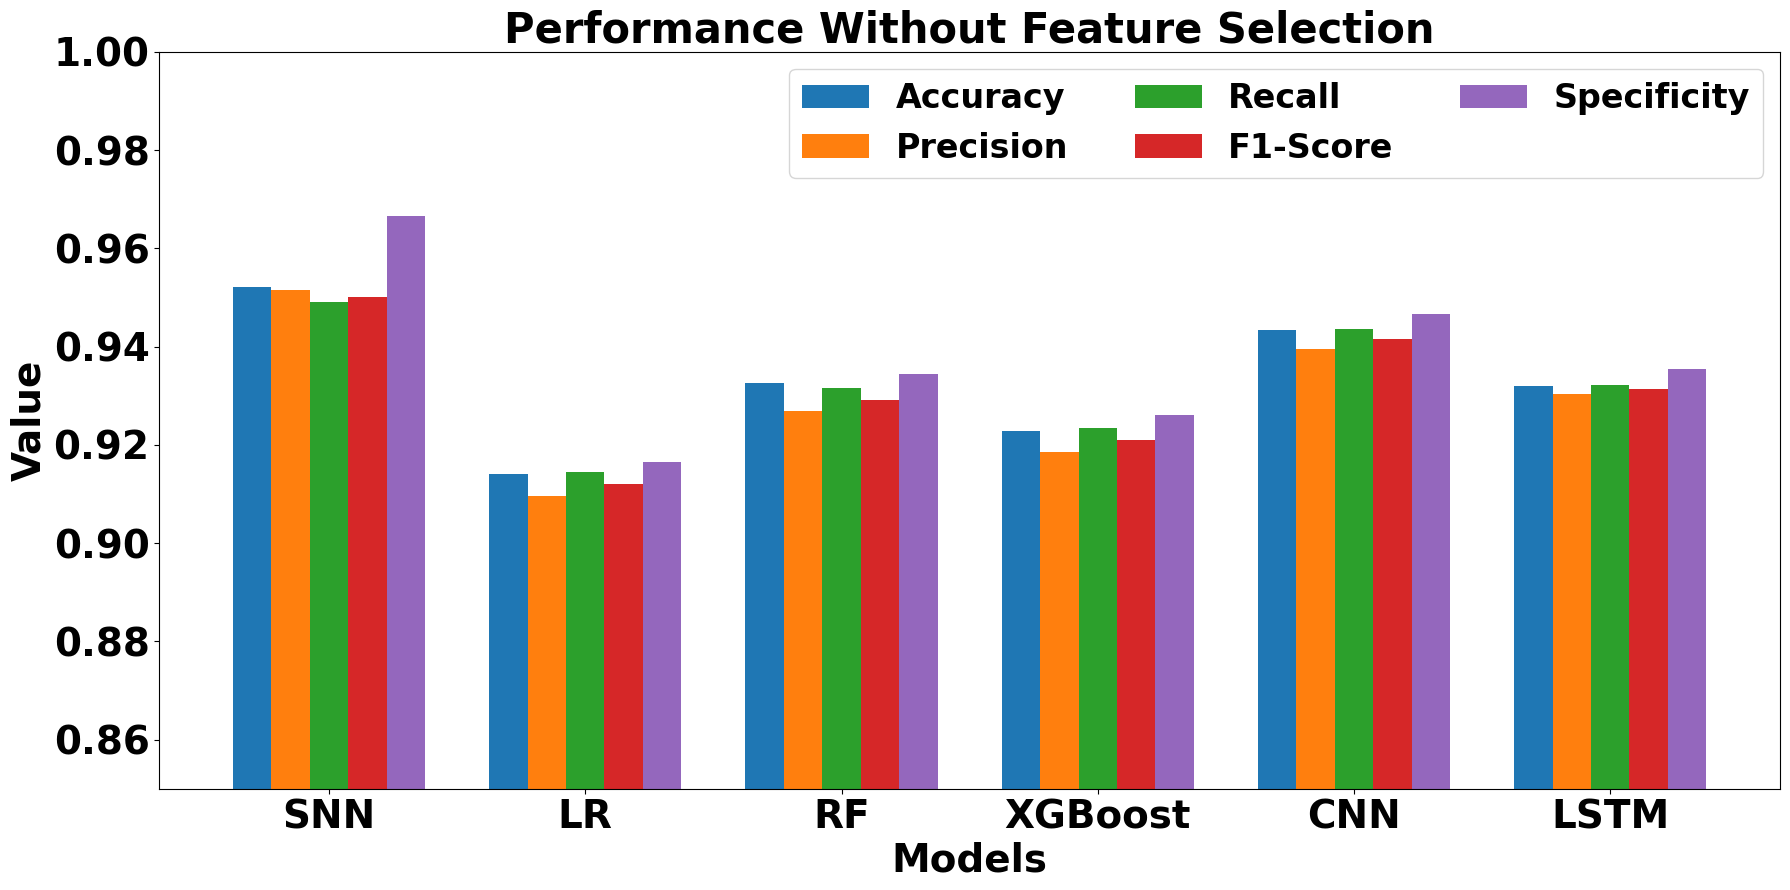

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Data (WITHOUT FEATURE SELECTION)
# =========================
models = ['SNN', 'LR', 'RF', 'XGBoost', 'CNN', 'LSTM']

accuracy    = [0.9522, 0.9140, 0.9326, 0.9228, 0.9434, 0.9320]
precision   = [0.9516, 0.9097, 0.9270, 0.9185, 0.9395, 0.9304]
recall      = [0.9491, 0.9144, 0.9315, 0.9234, 0.9437, 0.9323]
f1_score    = [0.9502, 0.9120, 0.9292, 0.9209, 0.9416, 0.9313]
specificity = [0.9667, 0.9165, 0.9344, 0.9260, 0.9466, 0.9355]

metrics = [
    accuracy, precision, recall, f1_score, specificity
]

metric_names = [
    'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity'
]

# =========================
# Bar Plot
# =========================
x = np.arange(len(models))
width = 0.15  # adjusted width (fewer metrics)

plt.figure(figsize=(18, 9))

for i, metric in enumerate(metrics):
    plt.bar(x + i * width, metric, width, label=metric_names[i])

# =========================
# Formatting
# =========================
plt.xlabel('Models', fontsize=28, fontweight='bold')
plt.ylabel('Value', fontsize=28, fontweight='bold')

plt.xticks(
    x + width * 2,  # center alignment
    models,
    fontsize=28,
    fontweight='bold'
)

plt.yticks(fontsize=28, fontweight='bold')
plt.ylim(0.85, 1.0)

# Legend
legend = plt.legend(
    fontsize=24,
    frameon=True,
    ncol=3
)
for text in legend.get_texts():
    text.set_fontweight('bold')

plt.title('Performance Without Feature Selection', fontsize=30, fontweight='bold')

plt.tight_layout()
plt.show()